In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load CSV file
df = pd.read_csv('urlspam.csv')


In [5]:
# Preview the data
df.head()

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34.0,20.0,28.0,119.0,0.0,124.0,1.0
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50.0,9.0,8.0,39.0,0.0,217.0,1.0
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10.0,2.0,7.0,42.0,2.0,5.0,1.0
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3.0,27.0,15.0,22.0,1.0,31.0,1.0
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244.0,15.0,34.0,72.0,1.0,85.0,1.0


In [7]:
#UNDERSTANDING THE DATASET
# Shape - how many rows & columns
print(df.shape)

(4712, 55)


In [8]:
# Column names
print(df.columns)

Index(['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD',
       'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb',
       'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation',
       'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL',
       'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL',
       'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL',
       'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS',
       'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title',
       'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots',
       'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription',
       'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet',
       'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay',
       'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS',
       'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'labe

In [9]:
# Data types of each column
print(df.dtypes)

URL                            object
URLLength                       int64
Domain                         object
DomainLength                    int64
IsDomainIP                      int64
TLD                            object
URLSimilarityIndex            float64
CharContinuationRate          float64
TLDLegitimateProb             float64
URLCharProb                   float64
TLDLength                       int64
NoOfSubDomain                   int64
HasObfuscation                  int64
NoOfObfuscatedChar              int64
ObfuscationRatio              float64
NoOfLettersInURL                int64
LetterRatioInURL              float64
NoOfDegitsInURL                 int64
DegitRatioInURL               float64
NoOfEqualsInURL                 int64
NoOfQMarkInURL                  int64
NoOfAmpersandInURL              int64
NoOfOtherSpecialCharsInURL      int64
SpacialCharRatioInURL         float64
IsHTTPS                         int64
LineOfCode                      int64
LargestLineL

In [10]:
# Statistical summary
df.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,4712.000000,4712.000000,4712.000000,4712.000000,4712.000000,4712.000000,4712.000000,4712.000000,4712.000000,4712.000000,...,4712.000000,4712.000000,4712.000000,4711.000000,4711.000000,4711.000000,4711.000000,4711.000000,4711.000000,4711.000000
mean,30.925297,20.795628,0.001486,84.250167,0.872909,0.266259,0.057038,2.760187,1.169779,0.001273,...,0.254881,0.027165,0.544779,31.497983,6.991934,12.344301,76.567820,2.593080,56.674379,0.659945
std,20.846742,7.842244,0.038519,25.321401,0.198915,0.250640,0.010043,0.590560,0.562799,0.035665,...,0.435841,0.162580,0.498044,88.487798,11.155642,26.165777,123.138487,12.124049,105.414157,0.473778
min,13.000000,4.000000,0.000000,1.727385,0.142857,0.000000,0.001223,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,69.052838,0.750000,0.008200,0.052810,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,19.000000,0.000000,100.000000,1.000000,0.079963,0.058937,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,13.000000,3.000000,7.000000,35.000000,0.000000,17.000000,1.000000
75%,32.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.063533,3.000000,1.000000,0.000000,...,1.000000,0.000000,1.000000,34.000000,9.000000,17.000000,106.000000,1.000000,69.000000,1.000000
max,472.000000,86.000000,1.000000,100.000000,1.000000,0.522907,0.082457,9.000000,5.000000,1.000000,...,1.000000,1.000000,1.000000,2326.000000,115.000000,1326.000000,1871.000000,475.000000,1873.000000,1.000000


In [11]:
# General info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4712 entries, 0 to 4711
Data columns (total 55 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   URL                         4712 non-null   object 
 1   URLLength                   4712 non-null   int64  
 2   Domain                      4712 non-null   object 
 3   DomainLength                4712 non-null   int64  
 4   IsDomainIP                  4712 non-null   int64  
 5   TLD                         4712 non-null   object 
 6   URLSimilarityIndex          4712 non-null   float64
 7   CharContinuationRate        4712 non-null   float64
 8   TLDLegitimateProb           4712 non-null   float64
 9   URLCharProb                 4712 non-null   float64
 10  TLDLength                   4712 non-null   int64  
 11  NoOfSubDomain               4712 non-null   int64  
 12  HasObfuscation              4712 non-null   int64  
 13  NoOfObfuscatedChar          4712 

In [12]:
#CHECKING FOR MISSING VALUE
# Count missing values per column
df.isnull().sum()

URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitleMatchScore         0
URLTitleMatchScore            0
HasFavic

In [13]:
# Percentage of missing values
df.isnull().sum() / len(df) * 100

URL                           0.000000
URLLength                     0.000000
Domain                        0.000000
DomainLength                  0.000000
IsDomainIP                    0.000000
TLD                           0.000000
URLSimilarityIndex            0.000000
CharContinuationRate          0.000000
TLDLegitimateProb             0.000000
URLCharProb                   0.000000
TLDLength                     0.000000
NoOfSubDomain                 0.000000
HasObfuscation                0.000000
NoOfObfuscatedChar            0.000000
ObfuscationRatio              0.000000
NoOfLettersInURL              0.000000
LetterRatioInURL              0.000000
NoOfDegitsInURL               0.000000
DegitRatioInURL               0.000000
NoOfEqualsInURL               0.000000
NoOfQMarkInURL                0.000000
NoOfAmpersandInURL            0.000000
NoOfOtherSpecialCharsInURL    0.000000
SpacialCharRatioInURL         0.000000
IsHTTPS                       0.000000
LineOfCode               

In [15]:
#CLEAN THE DATASET
# Option 1 - Drop rows with missing values
df = df.dropna()

In [22]:
df.isnull().sum()

URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitleMatchScore         0
URLTitleMatchScore            0
HasFavic

In [ ]:
# Option 2 - Fill missing values
df['column'] = df['column'].fillna(df['column'].mean())   # for numbers
df['column'] = df['column'].fillna('Unknown')             # for text



In [17]:
# Remove duplicate rows
df = df.drop_duplicates()

In [ ]:
# Fix wrong data types
df['age'] = df['age'].astype(int)

In [19]:
# Rename columns
df = df.rename(columns={'OldName': 'new_name'})

In [24]:
# Reset index after cleaning
df = df.reset_index(drop=True)

In [29]:
# ✅ Step 2: Check missing values BEFORE filling
print("Missing values BEFORE:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values BEFORE:
Series([], dtype: int64)


In [30]:
# Remove duplicate rows
df = df.drop_duplicates()

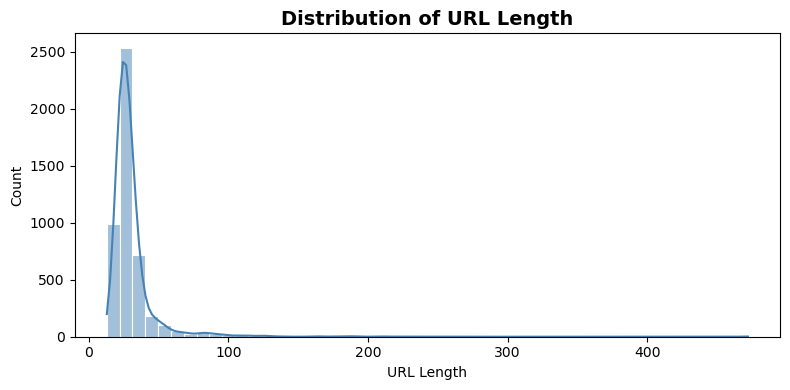

In [31]:
# Explore Data with Visualizations
# 1A: Distribution of URLLength
plt.figure(figsize=(8, 4))
sns.histplot(df['URLLength'], bins=50, kde=True, color='steelblue', edgecolor='white')
plt.title('Distribution of URL Length', fontsize=14, fontweight='bold')
plt.xlabel('URL Length')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

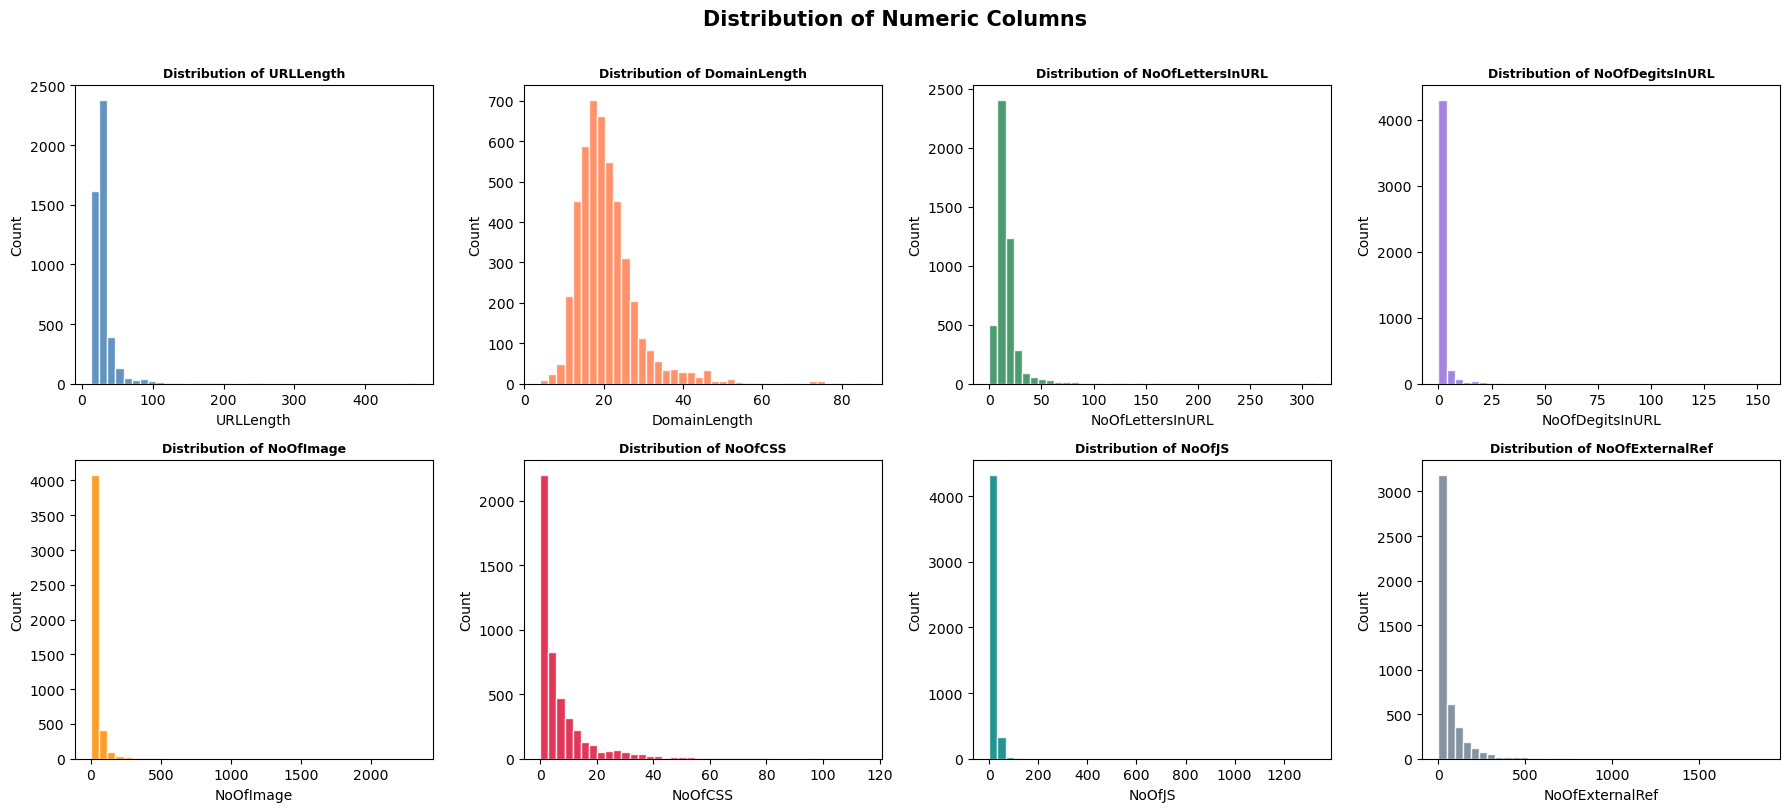

In [33]:
# 1B: Distribution of multiple numeric columns at once
num_features = ['URLLength', 'DomainLength', 'NoOfLettersInURL',
                'NoOfDegitsInURL', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfExternalRef']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
colors = ['steelblue','coral','seagreen','mediumpurple',
          'darkorange','crimson','teal','slategray']

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=40, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribution of {col}', fontsize=9, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Numeric Columns', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

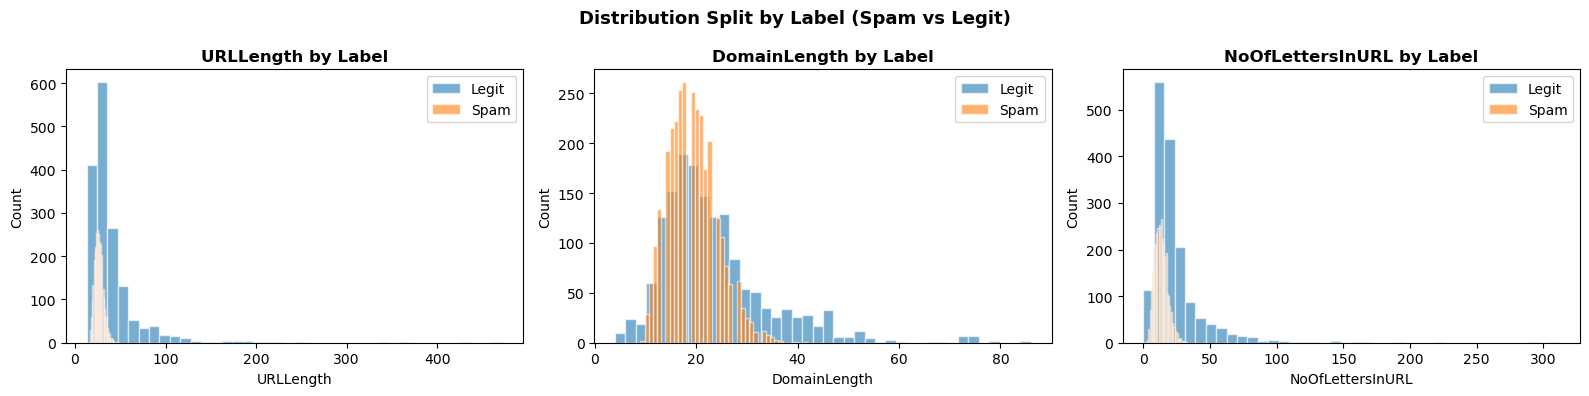

In [34]:
# 1C: Distribution split by Label (Spam vs Legit)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['URLLength', 'DomainLength', 'NoOfLettersInURL']):
    for label_val in [0, 1]:
        subset = df[df['label'] == label_val][col]
        ax.hist(subset, bins=40, alpha=0.6,
                label='Spam' if label_val == 1 else 'Legit',
                edgecolor='white')
    ax.set_title(f'{col} by Label', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Distribution Split by Label (Spam vs Legit)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\trisha\AppData\Local\Temp\ipykernel_24712\3245195748.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='label', palette=['steelblue', 'tomato'], edgecolor='black')


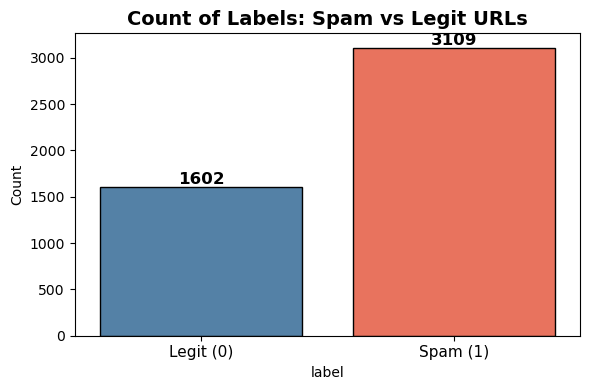

In [35]:
#COUNT OF CATEGORIES
# 2A: Label Count (Spam vs Legit)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='label', palette=['steelblue', 'tomato'], edgecolor='black')
plt.title('Count of Labels: Spam vs Legit URLs', fontsize=14, fontweight='bold')
plt.xticks([0, 1], ['Legit (0)', 'Spam (1)'], fontsize=11)
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

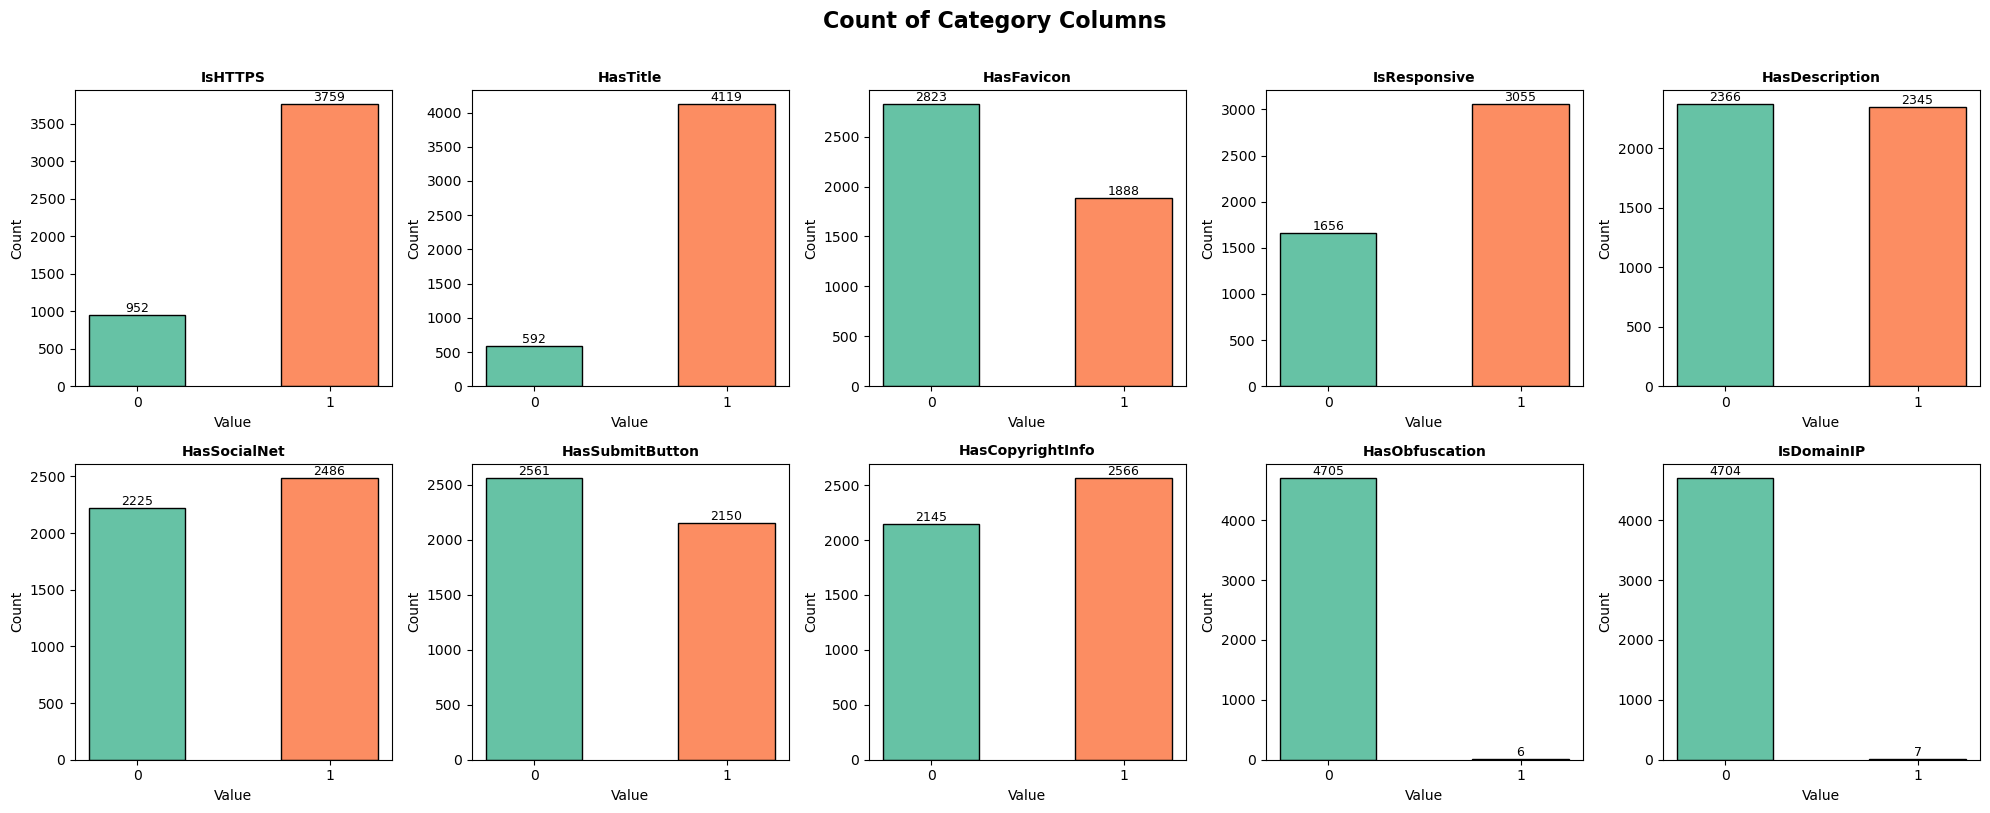

In [36]:
# 2B: Count of Binary/Category columns
cat_cols = ['IsHTTPS', 'HasTitle', 'HasFavicon', 'IsResponsive',
            'HasDescription', 'HasSocialNet', 'HasSubmitButton',
            'HasCopyrightInfo', 'HasObfuscation', 'IsDomainIP']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
palette = sns.color_palette('Set2', 2)

for i, col in enumerate(cat_cols):
    ax = axes[i]
    counts = df[col].value_counts().sort_index()
    bars = ax.bar(counts.index.astype(str), counts.values,
                  color=palette, edgecolor='black', width=0.5)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    for bar in bars:
        ax.annotate(f'{int(bar.get_height())}',
                    (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Count of Category Columns', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

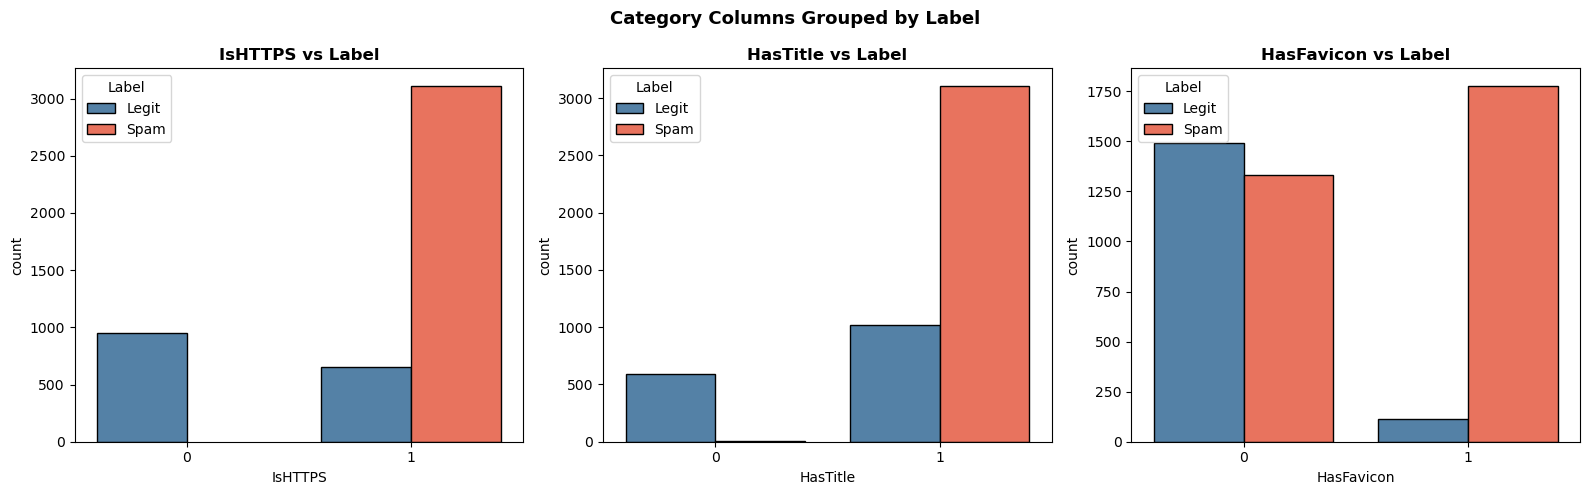

In [37]:
# 2C: Category counts grouped by Label
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ['IsHTTPS', 'HasTitle', 'HasFavicon']):
    sns.countplot(data=df, x=col, hue='label',
                  palette=['steelblue', 'tomato'], ax=ax, edgecolor='black')
    ax.set_title(f'{col} vs Label', fontweight='bold')
    ax.set_xlabel(col)
    ax.legend(title='Label', labels=['Legit', 'Spam'])

plt.suptitle('Category Columns Grouped by Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

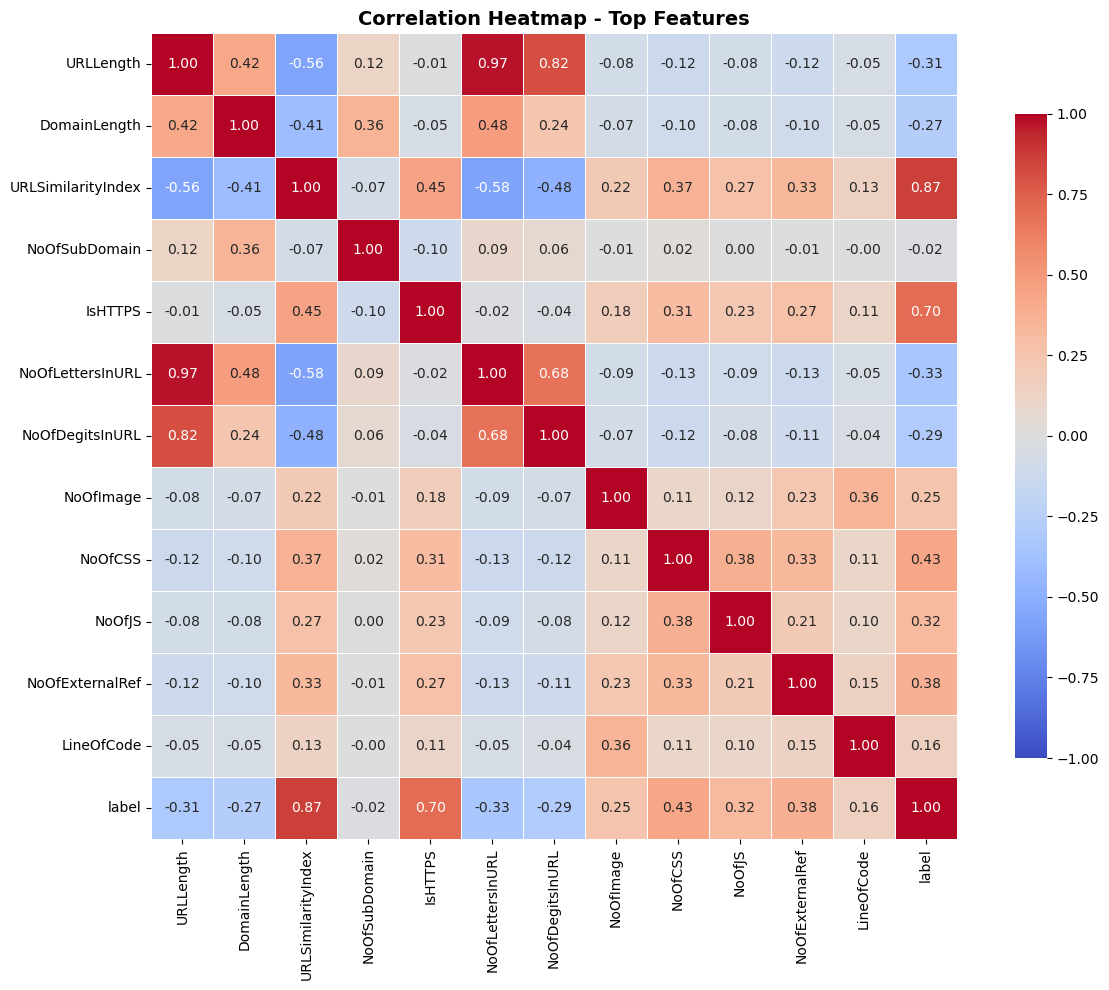

In [38]:
#CORRELATION HEATMAP
# 3A: Top Features Correlation Heatmap (with values)
top_cols = ['URLLength', 'DomainLength', 'URLSimilarityIndex',
            'NoOfSubDomain', 'IsHTTPS', 'NoOfLettersInURL',
            'NoOfDegitsInURL', 'NoOfImage', 'NoOfCSS',
            'NoOfJS', 'NoOfExternalRef', 'LineOfCode', 'label']

plt.figure(figsize=(13, 10))
sns.heatmap(df[top_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap - Top Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

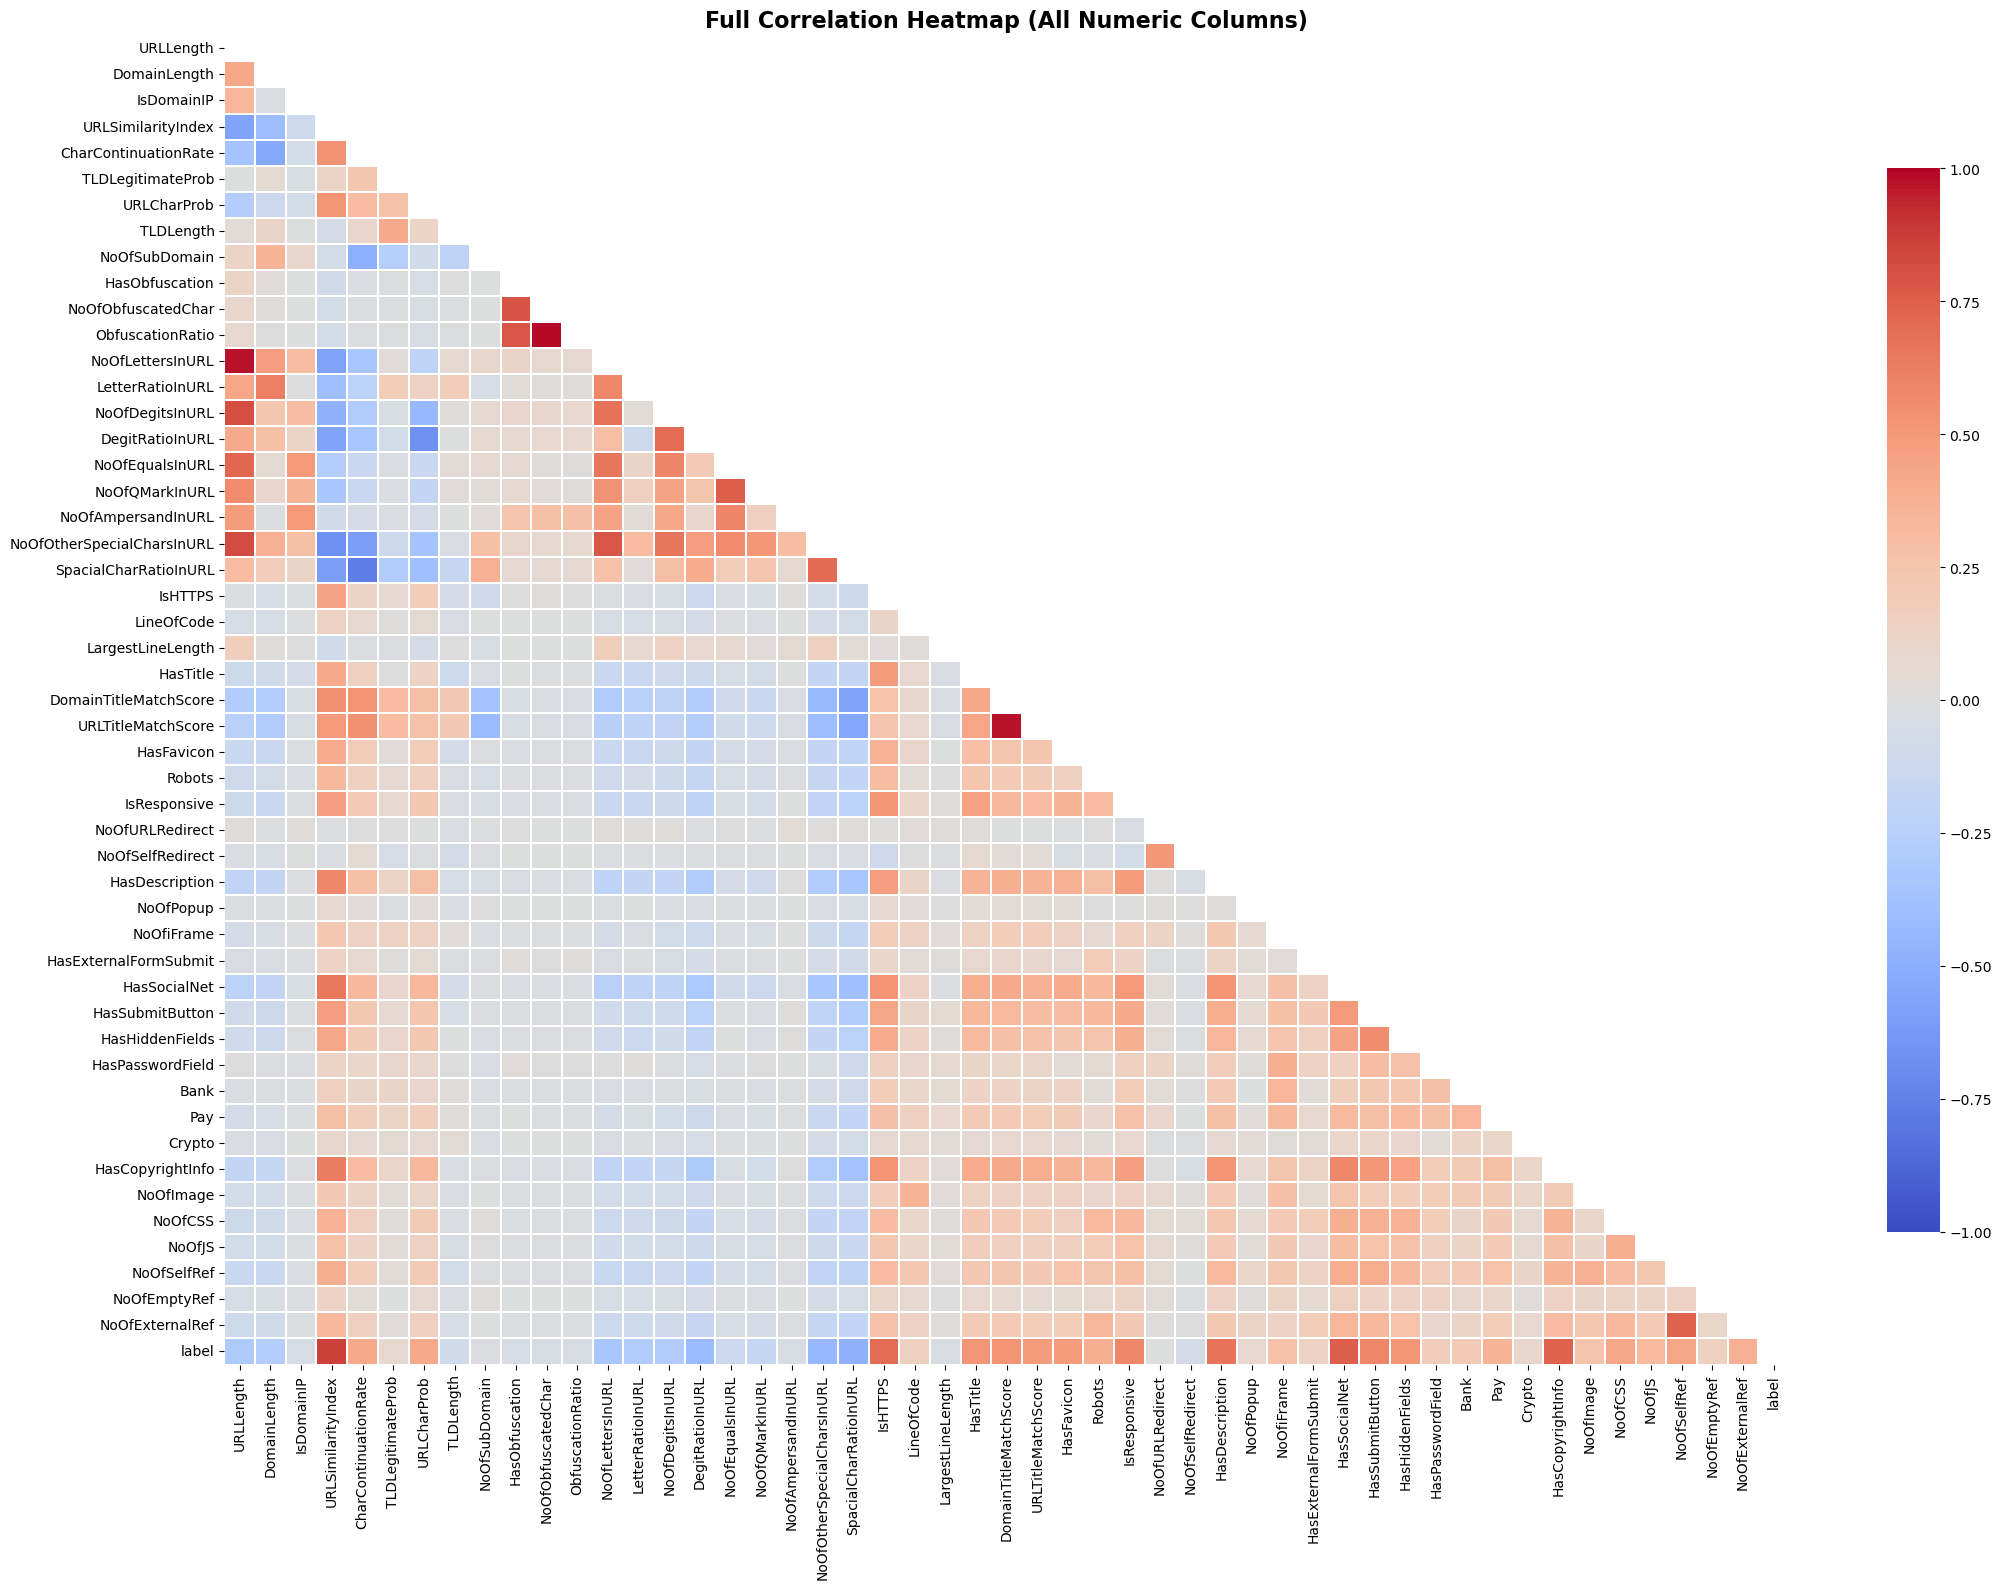

In [39]:
# 3B: Full Correlation Heatmap (all columns)
df_numeric = df.drop(columns=['URL', 'Domain', 'Title', 'TLD'])

plt.figure(figsize=(22, 16))
corr = df_numeric.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap='coolwarm',
            linewidths=0.3, vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
plt.title('Full Correlation Heatmap (All Numeric Columns)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

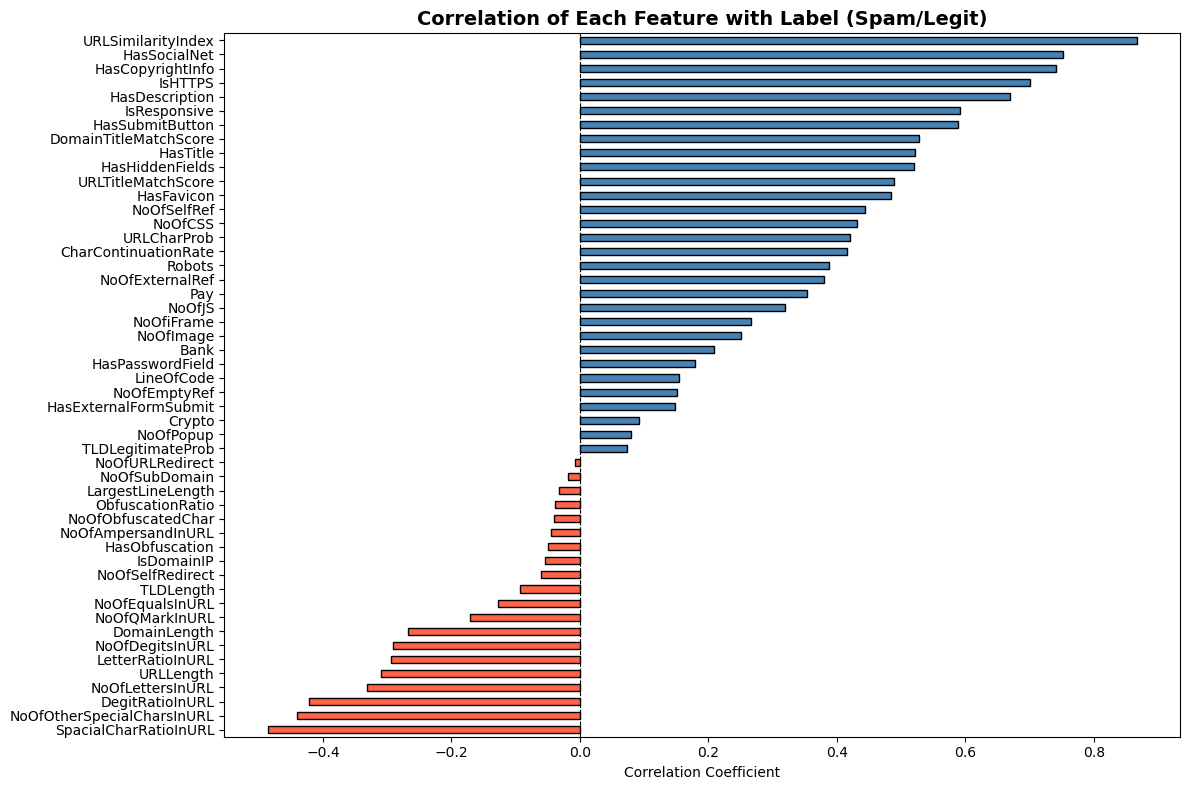

In [40]:
# 3C: Correlation with Label (bar chart - most important features)
label_corr = df_numeric.corr()['label'].drop('label').sort_values()

plt.figure(figsize=(12, 8))
colors = ['tomato' if v < 0 else 'steelblue' for v in label_corr]
label_corr.plot(kind='barh', color=colors, edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Correlation of Each Feature with Label (Spam/Legit)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

C:\Users\trisha\AppData\Local\Temp\ipykernel_24712\776807571.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=col,
C:\Users\trisha\AppData\Local\Temp\ipykernel_24712\776807571.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=col,
C:\Users\trisha\AppData\Local\Temp\ipykernel_24712\776807571.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y=col,
C:\Users\trisha\AppData\Local\Temp\ipykernel_24712\776807571.py:7: FutureWarning: 

Passing `palette` without assigning `hue` i

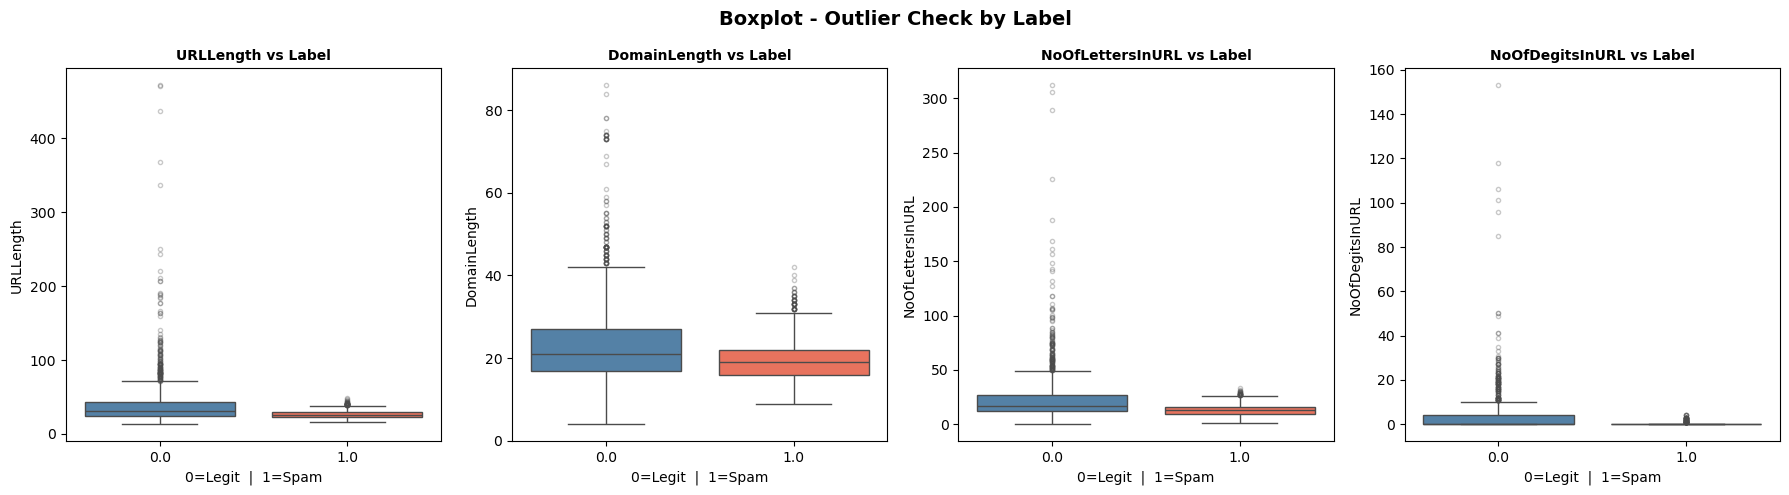

In [41]:
#BOXPLO CHECK FOR OUTLINER
# 4A: Boxplot grouped by Label for key columns
box_cols = ['URLLength', 'DomainLength', 'NoOfLettersInURL', 'NoOfDegitsInURL']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, box_cols):
    sns.boxplot(data=df, x='label', y=col,
                palette=['steelblue', 'tomato'], ax=ax,
                flierprops=dict(marker='o', color='gray', alpha=0.3, markersize=3))
    ax.set_title(f'{col} vs Label', fontweight='bold', fontsize=10)
    ax.set_xlabel('0=Legit  |  1=Spam')

plt.suptitle('Boxplot - Outlier Check by Label', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

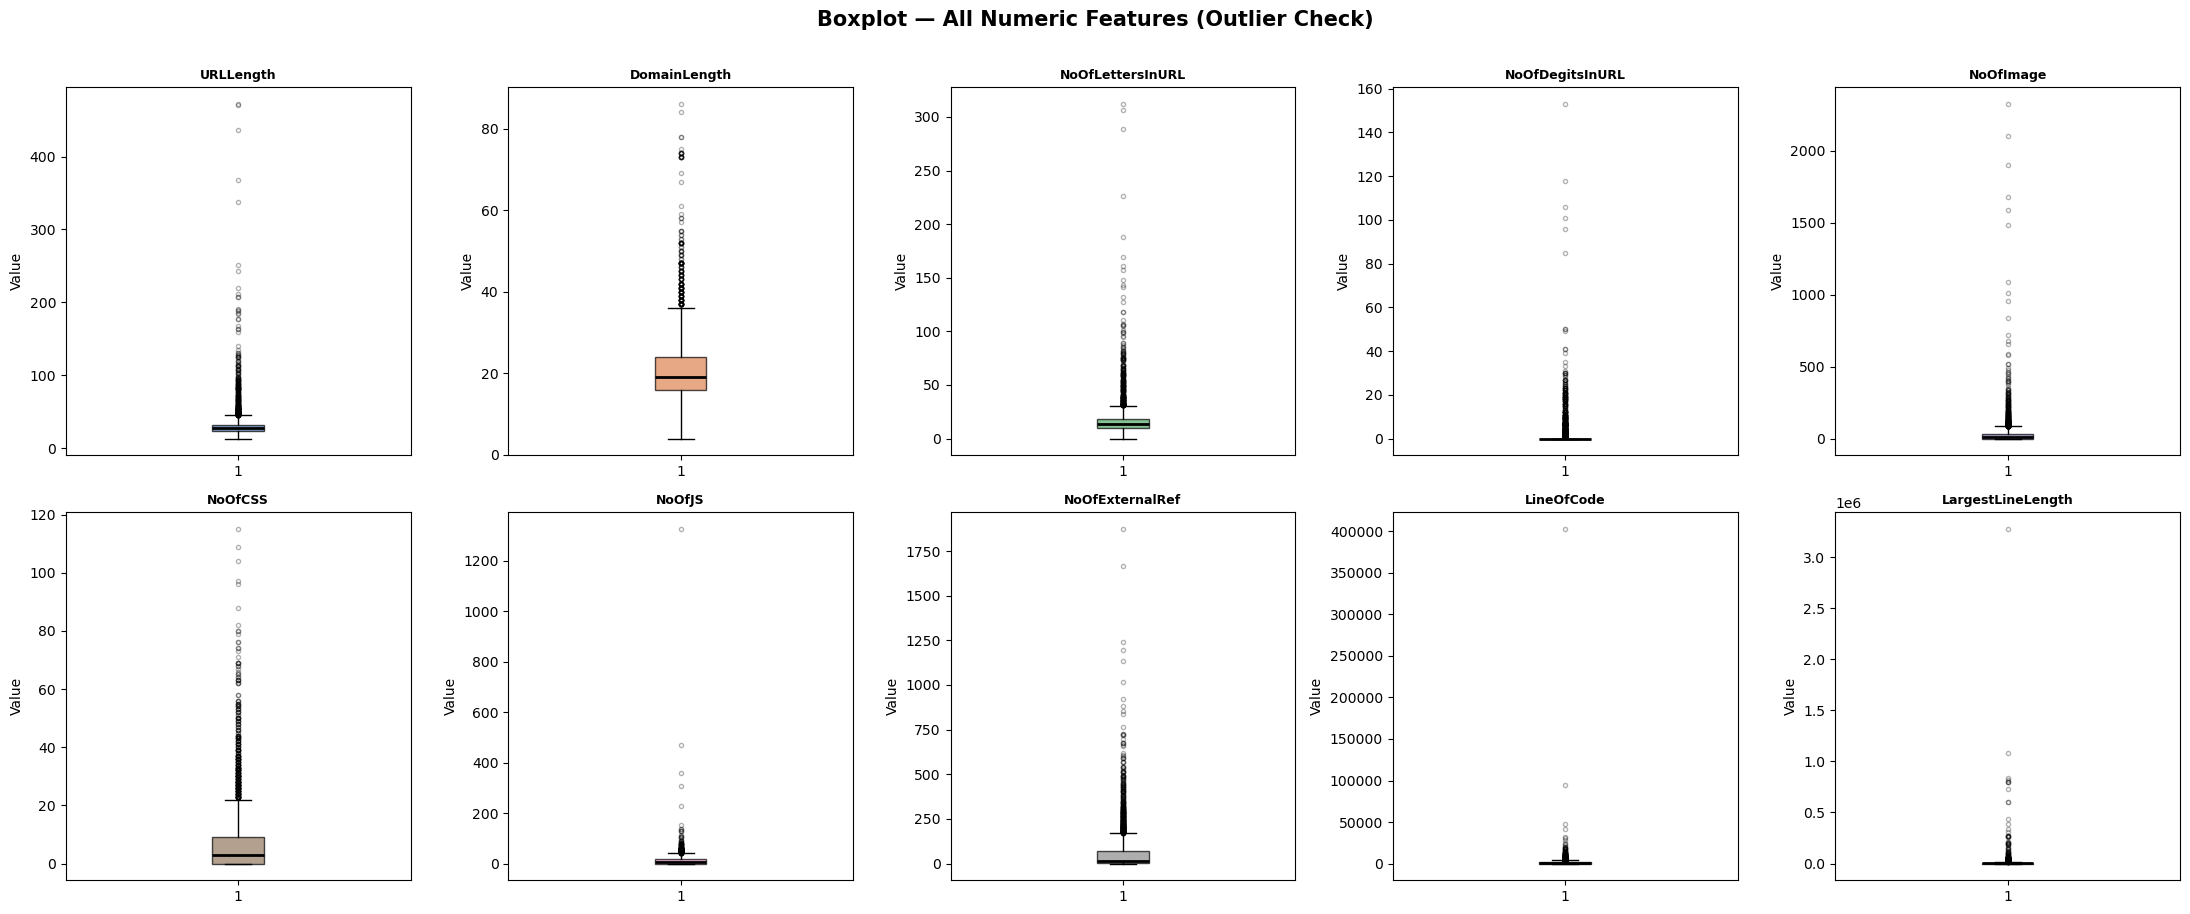

In [42]:
# 4B: Boxplot for all important numeric features
box_all = ['URLLength', 'DomainLength', 'NoOfLettersInURL', 'NoOfDegitsInURL',
           'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfExternalRef',
           'LineOfCode', 'LargestLineLength']

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3',
          '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']

for i, col in enumerate(box_all):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', color='red', alpha=0.3, markersize=3))
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Boxplot — All Numeric Features (Outlier Check)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [43]:
# 4C: Print Outlier Count Summary (IQR Method)
print('=== Outlier Summary (IQR Method) ===')
print(f'{"Column":<30} {"Outlier Count":>15} {"% of Total":>12}')
print('-' * 60)

for col in box_all:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)].shape[0]
    pct = (outliers / len(df)) * 100
    print(f'{col:<30} {outliers:>15} {pct:>11.2f}%')

=== Outlier Summary (IQR Method) ===
Column                           Outlier Count   % of Total
------------------------------------------------------------
URLLength                                  376        7.98%
DomainLength                               197        4.18%
NoOfLettersInURL                           312        6.62%
NoOfDegitsInURL                            739       15.69%
NoOfImage                                  358        7.60%
NoOfCSS                                    375        7.96%
NoOfJS                                     209        4.44%
NoOfExternalRef                            433        9.19%
LineOfCode                                 359        7.62%
LargestLineLength                          342        7.26%


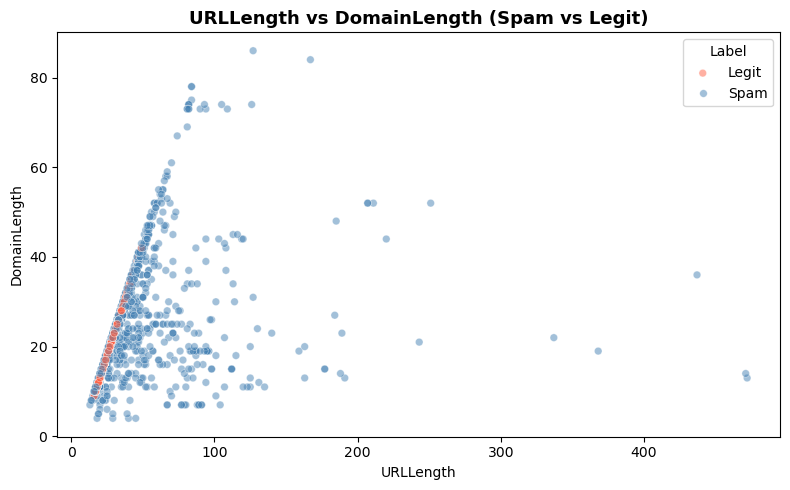

In [44]:
#relationship between two column
# 5A: Scatter Plot — URLLength vs DomainLength
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='URLLength', y='DomainLength',
                hue='label', palette=['steelblue', 'tomato'], alpha=0.5, s=30)
plt.title('URLLength vs DomainLength (Spam vs Legit)', fontsize=13, fontweight='bold')
plt.legend(title='Label', labels=['Legit', 'Spam'])
plt.tight_layout()
plt.show()

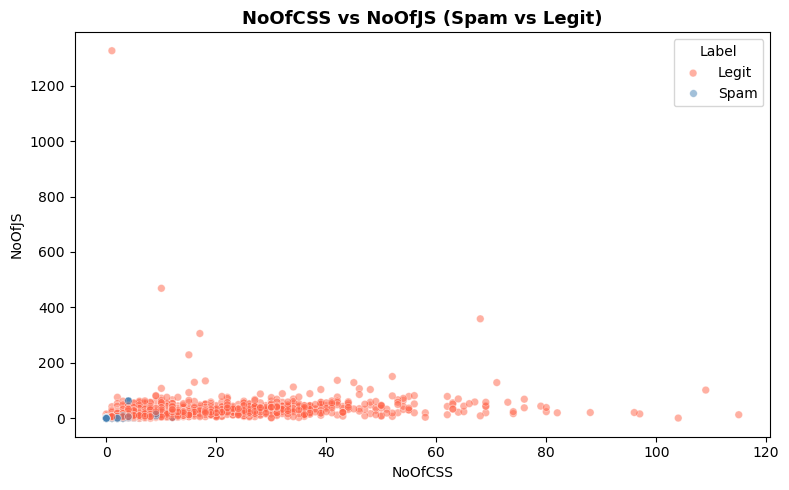

In [45]:
# 5B: Scatter Plot — NoOfCSS vs NoOfJS
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='NoOfCSS', y='NoOfJS',
                hue='label', palette=['steelblue', 'tomato'], alpha=0.5, s=30)
plt.title('NoOfCSS vs NoOfJS (Spam vs Legit)', fontsize=13, fontweight='bold')
plt.legend(title='Label', labels=['Legit', 'Spam'])
plt.tight_layout()
plt.show()

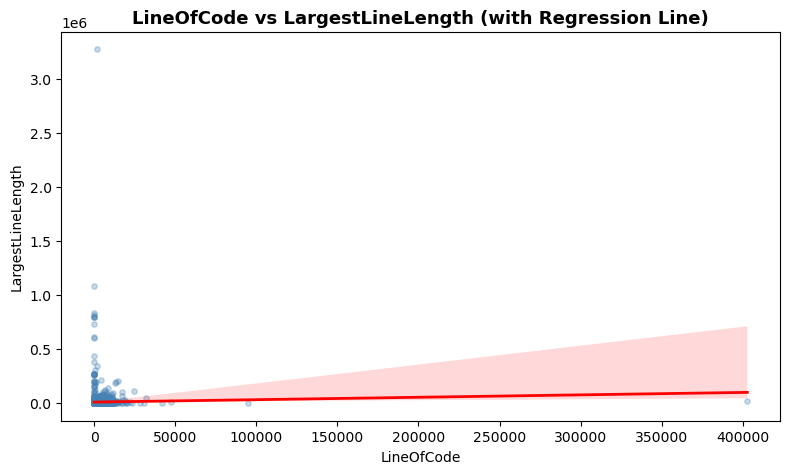

In [46]:
# 5C: Regression Line — LineOfCode vs LargestLineLength
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='LineOfCode', y='LargestLineLength',
            scatter_kws={'alpha': 0.3, 'color': 'steelblue', 's': 15},
            line_kws={'color': 'red', 'linewidth': 2})
plt.title('LineOfCode vs LargestLineLength (with Regression Line)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

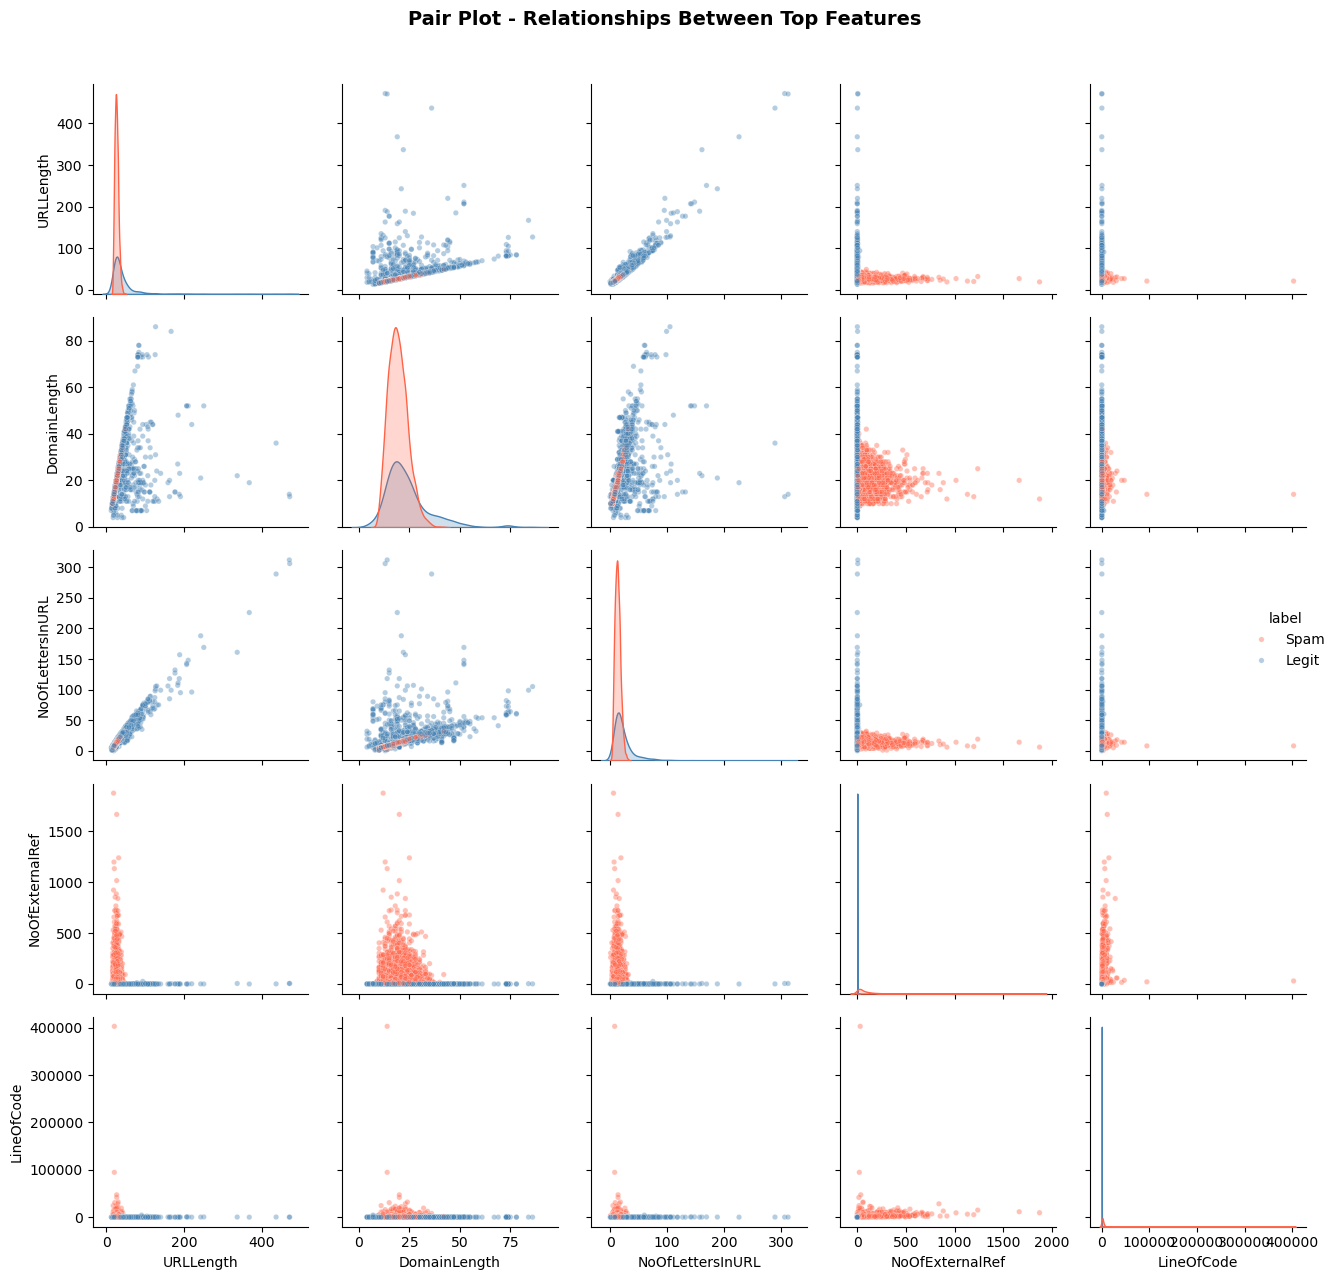

In [51]:
# 5D: Pair Plot — Top features + label
pair_cols = ['URLLength', 'DomainLength', 'NoOfLettersInURL',
             'NoOfExternalRef', 'LineOfCode', 'label']

pair_df = df[pair_cols].copy()
pair_df['label'] = pair_df['label'].map({0: 'Legit', 1: 'Spam'})

sns.pairplot(pair_df, hue='label',
             palette={'Legit': 'steelblue', 'Spam': 'tomato'},
             plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde')
plt.suptitle('Pair Plot - Relationships Between Top Features',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\trisha\AppData\Local\Temp\ipykernel_24712\2014720888.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df[df['label']==1]['URLSimilarityIndex'],


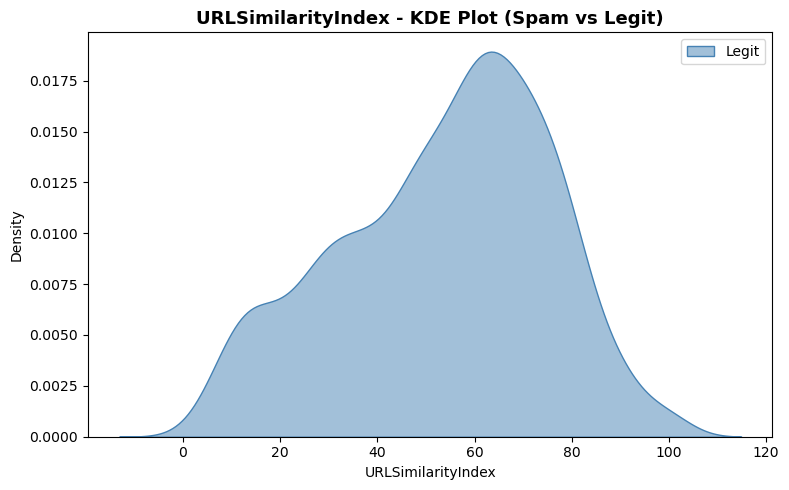

In [52]:
# 5E: KDE Plot — URLSimilarityIndex by Label
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df[df['label']==0]['URLSimilarityIndex'],
            label='Legit', fill=True, color='steelblue', alpha=0.5)
sns.kdeplot(data=df[df['label']==1]['URLSimilarityIndex'],
            label='Spam', fill=True, color='tomato', alpha=0.5)
plt.title('URLSimilarityIndex - KDE Plot (Spam vs Legit)',
          fontsize=13, fontweight='bold')
plt.xlabel('URLSimilarityIndex')
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
#FEATURE ENGINEERING
 Create new column: TotalRedirects
# Formula: NoOfURLRedirect + NoOfSelfRedirect

df['TotalRedirects'] = df['NoOfURLRedirect'] + df['NoOfSelfRedirect']

print('TotalRedirects - Statistics:')
print(df['TotalRedirects'].describe())
print()
print(df[['NoOfURLRedirect', 'NoOfSelfRedirect', 'TotalRedirects']].head(8))

IndentationError: unexpected indent (3628688976.py, line 2)

In [54]:
# Create new column: IsLongURL
# If URLLength is greater than 75 → 1 (Long URL)
# If URLLength is 75 or less   → 0 (Normal URL)

df['IsLongURL'] = (df['URLLength'] > 75).astype(int)

# Verify the new column
print('IsLongURL value counts:')
print(df['IsLongURL'].value_counts())
print()

# Show side by side
print(df[['URLLength', 'IsLongURL']].head(8))

IsLongURL value counts:
IsLongURL
0    4585
1     126
Name: count, dtype: int64

   URLLength  IsLongURL
0         31          0
1         23          0
2         29          0
3         26          0
4         33          0
5         30          0
6         25          0
7         25          0


In [55]:
# Create new column: DigitLetterRatio
# Formula: NoOfDegitsInURL divided by (NoOfLettersInURL + 1)
# We add +1 to avoid division by zero

df['DigitLetterRatio'] = df['NoOfDegitsInURL'] / (df['NoOfLettersInURL'] + 1)

# Round to 4 decimal places for readability
df['DigitLetterRatio'] = df['DigitLetterRatio'].round(4)

print('DigitLetterRatio - Statistics:')
print(df['DigitLetterRatio'].describe())
print()
print(df[['NoOfDegitsInURL', 'NoOfLettersInURL', 'DigitLetterRatio']].head(8))

DigitLetterRatio - Statistics:
count    4711.000000
mean        0.050769
std         0.225084
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        10.000000
Name: DigitLetterRatio, dtype: float64

   NoOfDegitsInURL  NoOfLettersInURL  DigitLetterRatio
0                0                18               0.0
1                0                 9               0.0
2                0                15               0.0
3                0                13               0.0
4                0                20               0.0
5                0                17               0.0
6                0                12               0.0
7                0                12               0.0


In [59]:
# Create new column: TotalRedirects
# Formula: NoOfURLRedirect + NoOfSelfRedirect

df['TotalRedirects'] = df['NoOfURLRedirect'] + df['NoOfSelfRedirect']

print('TotalRedirects - Statistics:')
print(df['TotalRedirects'].describe())
print()
print(df[['NoOfURLRedirect', 'NoOfSelfRedirect', 'TotalRedirects']].head(8))

TotalRedirects - Statistics:
count    4711.000000
mean        0.170877
std         0.466146
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         2.000000
Name: TotalRedirects, dtype: float64

   NoOfURLRedirect  NoOfSelfRedirect  TotalRedirects
0                0                 0               0
1                0                 0               0
2                0                 0               0
3                0                 0               0
4                1                 1               2
5                0                 0               0
6                1                 1               2
7                0                 0               0


In [60]:
# Create new column: ContentRichness
# Formula: NoOfImage + NoOfCSS + NoOfJS

df['ContentRichness'] = df['NoOfImage'] + df['NoOfCSS'] + df['NoOfJS']

print('ContentRichness - Statistics:')
print(df['ContentRichness'].describe())
print()
print(df[['NoOfImage', 'NoOfCSS', 'NoOfJS', 'ContentRichness']].head(8))

ContentRichness - Statistics:
count    4711.000000
mean       50.834218
std        98.067522
min         0.000000
25%         0.000000
50%        31.000000
75%        67.000000
max      2371.000000
Name: ContentRichness, dtype: float64

   NoOfImage  NoOfCSS  NoOfJS  ContentRichness
0       34.0     20.0    28.0             82.0
1       50.0      9.0     8.0             67.0
2       10.0      2.0     7.0             19.0
3        3.0     27.0    15.0             45.0
4      244.0     15.0    34.0            293.0
5       35.0      1.0    11.0             47.0
6       32.0      4.0    14.0             50.0
7       24.0      2.0    22.0             48.0


In [61]:
# Create new column: HasSuspiciousFeatures
# Condition: HasObfuscation=1 OR IsHTTPS=0 OR HasPasswordField=1
# If ANY suspicious feature is found → 1 (Suspicious), else → 0 (Clean)

df['HasSuspiciousFeatures'] = (
    (df['HasObfuscation'] == 1) |
    (df['IsHTTPS'] == 0) |
    (df['HasPasswordField'] == 1)
).astype(int)

print('HasSuspiciousFeatures value counts:')
print(df['HasSuspiciousFeatures'].value_counts())
print()
print(df[['HasObfuscation', 'IsHTTPS', 'HasPasswordField', 'HasSuspiciousFeatures']].head(10))

HasSuspiciousFeatures value counts:
HasSuspiciousFeatures
0    3278
1    1433
Name: count, dtype: int64

   HasObfuscation  IsHTTPS  HasPasswordField  HasSuspiciousFeatures
0               0        1                 0                      0
1               0        1                 0                      0
2               0        1                 0                      0
3               0        1                 0                      0
4               0        1                 0                      0
5               0        1                 0                      0
6               0        1                 0                      0
7               0        1                 0                      0
8               0        1                 1                      1
9               0        1                 0                      0


In [62]:
# Create new column: URLCategory
# Bins:  0-30 = Short,  31-60 = Medium,  61-100 = Long,  100+ = Very Long

df['URLCategory'] = pd.cut(
    df['URLLength'],
    bins=[0, 30, 60, 100, 9999],
    labels=['Short', 'Medium', 'Long', 'VeryLong']
)

print('URLCategory value counts:')
print(df['URLCategory'].value_counts())
print()
print(df[['URLLength', 'URLCategory']].head(10))

URLCategory value counts:
URLCategory
Short       3351
Medium      1175
Long         129
VeryLong      56
Name: count, dtype: int64

   URLLength URLCategory
0         31      Medium
1         23       Short
2         29       Short
3         26       Short
4         33      Medium
5         30       Short
6         25       Short
7         25       Short
8         29       Short
9         18       Short


C:\Users\trisha\AppData\Local\Temp\ipykernel_24712\259572241.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='DigitLetterRatio',
C:\Users\trisha\AppData\Local\Temp\ipykernel_24712\259572241.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label', y='TotalRedirects',


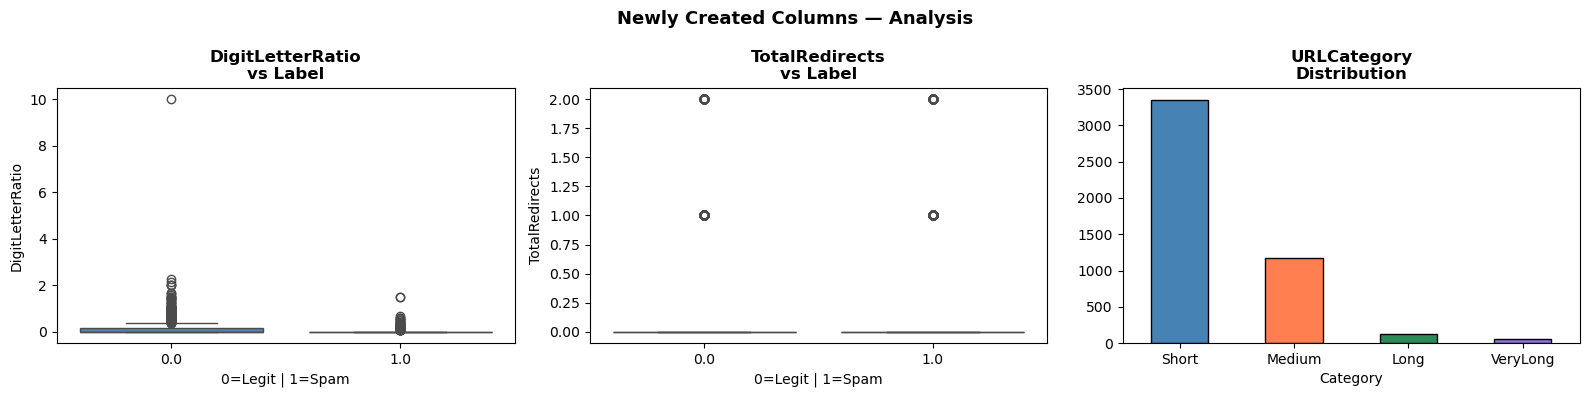

In [63]:
# Visualize: New columns vs Label
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# DigitLetterRatio by label
sns.boxplot(data=df, x='label', y='DigitLetterRatio',
            palette=['steelblue','tomato'], ax=axes[0])
axes[0].set_title('DigitLetterRatio\nvs Label', fontweight='bold')
axes[0].set_xlabel('0=Legit | 1=Spam')

# TotalRedirects by label
sns.boxplot(data=df, x='label', y='TotalRedirects',
            palette=['steelblue','tomato'], ax=axes[1])
axes[1].set_title('TotalRedirects\nvs Label', fontweight='bold')
axes[1].set_xlabel('0=Legit | 1=Spam')

# URLCategory count
df['URLCategory'].value_counts().plot(kind='bar', ax=axes[2],
    color=['steelblue','coral','seagreen','mediumpurple'], edgecolor='black')
axes[2].set_title('URLCategory\nDistribution', fontweight='bold')
axes[2].set_xlabel('Category')
axes[2].tick_params(axis='x', rotation=0)

plt.suptitle('Newly Created Columns — Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [64]:
# Show all new columns added so far
new_cols = ['IsLongURL', 'DigitLetterRatio', 'TotalRedirects',
            'ContentRichness', 'HasSuspiciousFeatures', 'URLCategory']

print('=== All Newly Created Columns ===')
print(df[new_cols].head(10))

=== All Newly Created Columns ===
   IsLongURL  DigitLetterRatio  TotalRedirects  ContentRichness  \
0          0               0.0               0             82.0   
1          0               0.0               0             67.0   
2          0               0.0               0             19.0   
3          0               0.0               0             45.0   
4          0               0.0               2            293.0   
5          0               0.0               0             47.0   
6          0               0.0               2             50.0   
7          0               0.0               0             48.0   
8          0               0.0               0             84.0   
9          0               0.0               0             23.0   

   HasSuspiciousFeatures URLCategory  
0                      0      Medium  
1                      0       Short  
2                      0       Short  
3                      0       Short  
4                      0      Med

In [65]:
# First, let's see which columns still need encoding
print('=== Columns that need Encoding ===')
for col in df.columns:
    if df[col].dtype == 'object' or str(df[col].dtype) == 'category':
        print(f'  Column: {col}  |  Type: {df[col].dtype}  |  Unique values: {df[col].nunique()}')

=== Columns that need Encoding ===
  Column: URL  |  Type: object  |  Unique values: 4711
  Column: Domain  |  Type: object  |  Unique values: 4663
  Column: TLD  |  Type: object  |  Unique values: 195
  Column: Title  |  Type: object  |  Unique values: 4109
  Column: URLCategory  |  Type: category  |  Unique values: 4


In [66]:
# METHOD 2: Label Encoding using sklearn's LabelEncoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['TLD_Encoded'] = le.fit_transform(df['TLD'])

print('=== TLD — Before and After Encoding ===')
print(df[['TLD', 'TLD_Encoded']].head(12))
print()
print(f'Total unique TLDs: {df["TLD"].nunique()}')
print()
print('Encoding mapping (first 10):')
mapping_df = pd.DataFrame({'TLD': le.classes_, 'Encoded': range(len(le.classes_))})
print(mapping_df.head(10))

=== TLD — Before and After Encoding ===
    TLD  TLD_Encoded
0   com           41
1    de           47
2    uk          182
3   com           41
4   org          136
5   org          136
6   com           41
7   com           41
8    in           87
9   org          136
10  com           41
11  com           41

Total unique TLDs: 195

Encoding mapping (first 10):
      TLD  Encoded
0     103        0
1     123        1
2     128        2
3     130        3
4      94        4
5      ae        5
6    aero        6
7  agency        7
8      ai        8
9      am        9


In [67]:
# METHOD 3: One-Hot Encoding using pd.get_dummies()
# Step 1: Get top 10 most common TLDs
top10_tlds = df['TLD'].value_counts().head(10).index.tolist()
print('Top 10 TLDs:', top10_tlds)
print()

# Step 2: Replace rare TLDs with 'other'
df['TLD_grouped'] = df['TLD'].where(df['TLD'].isin(top10_tlds), 'other')

# Step 3: Apply One-Hot Encoding
tld_dummies = pd.get_dummies(df['TLD_grouped'], prefix='TLD')

# Step 4: Add the new columns to the dataframe
df = pd.concat([df, tld_dummies], axis=1)

print('One-Hot Encoded TLD columns created:')
print([c for c in df.columns if c.startswith('TLD_')])
print()
print('Sample of encoded columns:')
print(df[['TLD'] + [c for c in df.columns if c.startswith('TLD_')]].head(8))

Top 10 TLDs: ['com', 'org', 'net', 'uk', 'de', 'co', 'app', 'ru', 'io', 'top']

One-Hot Encoded TLD columns created:
['TLD_Encoded', 'TLD_grouped', 'TLD_app', 'TLD_co', 'TLD_com', 'TLD_de', 'TLD_io', 'TLD_net', 'TLD_org', 'TLD_other', 'TLD_ru', 'TLD_top', 'TLD_uk']

Sample of encoded columns:
   TLD  TLD_Encoded TLD_grouped  TLD_app  TLD_co  TLD_com  TLD_de  TLD_io  \
0  com           41         com    False   False     True   False   False   
1   de           47          de    False   False    False    True   False   
2   uk          182          uk    False   False    False   False   False   
3  com           41         com    False   False     True   False   False   
4  org          136         org    False   False    False   False   False   
5  org          136         org    False   False    False   False   False   
6  com           41         com    False   False     True   False   False   
7  com           41         com    False   False     True   False   False   

   TLD_net  

In [68]:
# METHOD 4: Frequency Encoding
# Replace each TLD with how frequently it appears in the dataset

tld_freq = df['TLD'].value_counts(normalize=True)  # percentage frequency
df['TLD_FreqEncoded'] = df['TLD'].map(tld_freq)

print('=== TLD Frequency Encoding ===')
print(df[['TLD', 'TLD_FreqEncoded']].head(12))
print()
print('Top 5 TLD frequencies:')
print(tld_freq.head(5))

=== TLD Frequency Encoding ===
    TLD  TLD_FreqEncoded
0   com         0.486309
1    de         0.022713
2    uk         0.028869
3   com         0.486309
4   org         0.091063
5   org         0.091063
6   com         0.486309
7   com         0.486309
8    in         0.004245
9   org         0.091063
10  com         0.486309
11  com         0.486309

Top 5 TLD frequencies:
TLD
com    0.486309
org    0.091063
net    0.031840
uk     0.028869
de     0.022713
Name: proportion, dtype: float64


In [69]:
summary = pd.DataFrame({
    'Method': ['Label Encoding (map)', 'LabelEncoder (sklearn)', 'One-Hot Encoding', 'Frequency Encoding'],
    'Best For': [
        'Ordered categories (Short < Medium < Long)',
        'Many categories, no order (TLD: com, net, org...)',
        'Few categories, no order (< 10 unique values)',
        'High-cardinality columns (100+ unique values)'
    ],
    'Used On': ['URLCategory', 'TLD', 'TLD (top 10 only)', 'TLD'],
    'Creates New Columns': ['No', 'No', 'Yes (1 per category)', 'No']
})
print(summary.to_string(index=False))

                Method                                          Best For           Used On  Creates New Columns
  Label Encoding (map)        Ordered categories (Short < Medium < Long)       URLCategory                   No
LabelEncoder (sklearn) Many categories, no order (TLD: com, net, org...)               TLD                   No
      One-Hot Encoding     Few categories, no order (< 10 unique values) TLD (top 10 only) Yes (1 per category)
    Frequency Encoding     High-cardinality columns (100+ unique values)               TLD                   No


In [70]:
# First, check current shape and columns
print('Shape BEFORE dropping:', df.shape)
print('Total columns:', len(df.columns))

Shape BEFORE dropping: (4711, 75)
Total columns: 75


In [71]:
# Drop text columns: URL, Domain, Title
# These are raw strings — ML models cannot use them directly
# We already extracted useful info from them (URLLength, DomainLength, etc.)

cols_to_drop_text = ['URL', 'Domain', 'Title']

df = df.drop(columns=cols_to_drop_text)

print('Dropped text columns:', cols_to_drop_text)
print('Shape after dropping text columns:', df.shape)

Dropped text columns: ['URL', 'Domain', 'Title']
Shape after dropping text columns: (4711, 72)


In [72]:
# Drop the original TLD text column and the intermediate TLD_grouped column
# because we already created TLD_Encoded, TLD_FreqEncoded, and TLD_* dummies

cols_to_drop_encoded = ['TLD', 'TLD_grouped']

df = df.drop(columns=cols_to_drop_encoded)

print('Dropped after encoding:', cols_to_drop_encoded)
print('Shape after dropping:', df.shape)

Dropped after encoding: ['TLD', 'TLD_grouped']
Shape after dropping: (4711, 70)


In [73]:
# Drop raw count columns where we already have ratio columns
# LetterRatioInURL  already captures NoOfLettersInURL as a ratio
# DegitRatioInURL   already captures NoOfDegitsInURL as a ratio
# ObfuscationRatio  already captures NoOfObfuscatedChar as a ratio

cols_to_drop_redundant = [
    'NoOfLettersInURL',   # already have LetterRatioInURL
    'NoOfDegitsInURL',    # already have DegitRatioInURL
    'NoOfObfuscatedChar', # already have ObfuscationRatio
]

df = df.drop(columns=cols_to_drop_redundant)

print('Dropped redundant columns:', cols_to_drop_redundant)
print('Shape after dropping:', df.shape)

Dropped redundant columns: ['NoOfLettersInURL', 'NoOfDegitsInURL', 'NoOfObfuscatedChar']
Shape after dropping: (4711, 67)


In [74]:
# Drop URLCategory (text version) since we have URLCategory_Encoded (numeric)

df = df.drop(columns=['URLCategory'])

print('Dropped intermediate column: URLCategory')
print('Shape after dropping:', df.shape)

Dropped intermediate column: URLCategory
Shape after dropping: (4711, 66)


In [75]:
# Find columns with very low variance (almost all values are the same)
# Select only numeric columns for variance calculation
numeric_df = df.select_dtypes(include=[np.number])
variance = numeric_df.var().sort_values()

print('=== Columns with LOWEST Variance (potentially useless) ===')
print(variance.head(10))
print()

# Drop columns where variance is less than 0.01
low_variance_cols = variance[variance < 0.01].index.tolist()
print('Columns with variance < 0.01:', low_variance_cols)

if low_variance_cols:
    df = df.drop(columns=low_variance_cols)
    print('Dropped low variance columns:', low_variance_cols)
else:
    print('No columns with variance < 0.01 found — all columns are kept!')

=== Columns with LOWEST Variance (potentially useless) ===
ObfuscationRatio         0.000010
URLCharProb              0.000101
SpacialCharRatioInURL    0.000862
HasObfuscation           0.001272
IsDomainIP               0.001484
DegitRatioInURL          0.003925
LetterRatioInURL         0.013023
NoOfQMarkInURL           0.022172
IsLongURL                0.026036
Crypto                   0.026438
dtype: float64

Columns with variance < 0.01: ['ObfuscationRatio', 'URLCharProb', 'SpacialCharRatioInURL', 'HasObfuscation', 'IsDomainIP', 'DegitRatioInURL']
Dropped low variance columns: ['ObfuscationRatio', 'URLCharProb', 'SpacialCharRatioInURL', 'HasObfuscation', 'IsDomainIP', 'DegitRatioInURL']


In [76]:
# If you want to drop multiple columns together — use a list
# This is the cleanest and most common way to drop several at once

# Example: drop columns that are not needed for the final ML model
cols_final_drop = ['NoOfPopup', 'NoOfSelfRedirect']
# Note: NoOfSelfRedirect is already captured in TotalRedirects (our new column)

df = df.drop(columns=cols_final_drop)

print('Dropped final columns:', cols_final_drop)
print('Final Shape:', df.shape)

Dropped final columns: ['NoOfPopup', 'NoOfSelfRedirect']
Final Shape: (4711, 58)


In [77]:
print('=' * 55)
print('         FEATURE ENGINEERING SUMMARY')
print('=' * 55)
print(f'  Original Shape        :  4712 rows × 55 columns')
print(f'  Final Shape           :  {df.shape[0]} rows × {df.shape[1]} columns')
print()
print('  NEW Columns Added:')
new_cols_added = ['IsLongURL', 'DigitLetterRatio', 'TotalRedirects',
                  'ContentRichness', 'HasSuspiciousFeatures',
                  'URLCategory_Encoded', 'TLD_Encoded', 'TLD_FreqEncoded']
for c in new_cols_added:
    if c in df.columns:
        print(f'    ✅ {c}')
print()
print('  Columns DROPPED:')
for c in ['URL', 'Domain', 'Title', 'TLD', 'TLD_grouped',
          'URLCategory', 'NoOfLettersInURL', 'NoOfDegitsInURL',
          'NoOfObfuscatedChar', 'NoOfPopup', 'NoOfSelfRedirect']:
    print(f'    ❌ {c}')
print()
print('  Final column list:')
for i, col in enumerate(df.columns, 1):
    print(f'    {i:02d}. {col}')

         FEATURE ENGINEERING SUMMARY
  Original Shape        :  4712 rows × 55 columns
  Final Shape           :  4711 rows × 58 columns

  NEW Columns Added:
    ✅ IsLongURL
    ✅ DigitLetterRatio
    ✅ TotalRedirects
    ✅ ContentRichness
    ✅ HasSuspiciousFeatures
    ✅ TLD_Encoded
    ✅ TLD_FreqEncoded

  Columns DROPPED:
    ❌ URL
    ❌ Domain
    ❌ Title
    ❌ TLD
    ❌ TLD_grouped
    ❌ URLCategory
    ❌ NoOfLettersInURL
    ❌ NoOfDegitsInURL
    ❌ NoOfObfuscatedChar
    ❌ NoOfPopup
    ❌ NoOfSelfRedirect

  Final column list:
    01. URLLength
    02. DomainLength
    03. URLSimilarityIndex
    04. CharContinuationRate
    05. TLDLegitimateProb
    06. TLDLength
    07. NoOfSubDomain
    08. LetterRatioInURL
    09. NoOfEqualsInURL
    10. NoOfQMarkInURL
    11. NoOfAmpersandInURL
    12. NoOfOtherSpecialCharsInURL
    13. IsHTTPS
    14. LineOfCode
    15. LargestLineLength
    16. HasTitle
    17. DomainTitleMatchScore
    18. URLTitleMatchScore
    19. HasFavicon
    20. Ro

In [78]:
# Verify all columns are now numeric (ready for ML)
non_numeric = df.select_dtypes(include=['object', 'category']).columns.tolist()

if len(non_numeric) == 0:
    print('✅ ALL columns are numeric — dataset is ready for Machine Learning!')
else:
    print('⚠️  These columns still need encoding:', non_numeric)

print()
print('Final Dataset Preview:')
df.head(5)

✅ ALL columns are numeric — dataset is ready for Machine Learning!

Final Dataset Preview:


,URLLength,DomainLength,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,TLDLength,NoOfSubDomain,LetterRatioInURL,NoOfEqualsInURL,NoOfQMarkInURL,...,TLD_com,TLD_de,TLD_io,TLD_net,TLD_org,TLD_other,TLD_ru,TLD_top,TLD_uk,TLD_FreqEncoded
0,31,24,100.0,1.000000,0.522907,3,1,0.581,0,0,...,True,False,False,False,False,False,False,False,False,0.486309
1,23,16,100.0,0.666667,0.032650,2,1,0.391,0,0,...,False,True,False,False,False,False,False,False,False,0.022713
2,29,22,100.0,0.866667,0.028555,2,2,0.517,0,0,...,False,False,False,False,False,False,False,False,True,0.028869
3,26,19,100.0,1.000000,0.522907,3,1,0.500,0,0,...,True,False,False,False,False,False,False,False,False,0.486309
4,33,26,100.0,1.000000,0.079963,3,1,0.606,0,0,...,False,False,False,False,True,False,False,False,False,0.091063


In [79]:
# Save the final engineered dataset
df.to_csv('urlspam_engineered.csv', index=False)
print('✅ Engineered dataset saved as: urlspam_engineered.csv')

✅ Engineered dataset saved as: urlspam_engineered.csv


In [80]:
# ── Step 1: Check the target column first ─────────────────────────────────
print('=== Target Column: label ===')
print(df['label'].value_counts())
print()
print('  0.0 = Legitimate URL')
print('  1.0 = Spam URL')
print()
print(f'  Total Spam  (1): {int(df["label"].sum())}')
print(f'  Total Legit (0): {int((df["label"]==0).sum())}')
print(f'  Spam  % : {df["label"].mean()*100:.1f}%')
print(f'  Legit % : {(1-df["label"].mean())*100:.1f}%')

=== Target Column: label ===
label
1.0    3109
0.0    1602
Name: count, dtype: int64

  0.0 = Legitimate URL
  1.0 = Spam URL

  Total Spam  (1): 3109
  Total Legit (0): 1602
  Spam  % : 66.0%
  Legit % : 34.0%


In [82]:
# ── Step 2: Separate X (Features) and y (Target) ──────────────────────────

# X = All columns EXCEPT the target column 'label'
X = df.drop(columns=['label'])

# y = ONLY the target column 'label'
y = df['label']

print('=== X — Features (Input to model) ===')
print(f'  Shape          : {X.shape}')
print(f'  Number of rows : {X.shape[0]}')
print(f'  Number of cols : {X.shape[1]}')
print()
print('=== y — Target (What model predicts) ===')
print(f'  Shape : {y.shape}')
print(f'  Values: {y.unique()}')

=== X — Features (Input to model) ===
  Shape          : (4711, 57)
  Number of rows : 4711
  Number of cols : 57

=== y — Target (What model predicts) ===
  Shape : (4711,)
  Values: [1. 0.]


In [83]:
# ── Step 3: View all feature columns (X) ──────────────────────────────────
print('=== All Feature Columns in X ===')
print(f'Total: {len(X.columns)} features\n')
for i, col in enumerate(X.columns, 1):
    print(f'  {i:02d}. {col}  ({X[col].dtype})')

=== All Feature Columns in X ===
Total: 57 features

  01. URLLength  (int64)
  02. DomainLength  (int64)
  03. URLSimilarityIndex  (float64)
  04. CharContinuationRate  (float64)
  05. TLDLegitimateProb  (float64)
  06. TLDLength  (int64)
  07. NoOfSubDomain  (int64)
  08. LetterRatioInURL  (float64)
  09. NoOfEqualsInURL  (int64)
  10. NoOfQMarkInURL  (int64)
  11. NoOfAmpersandInURL  (int64)
  12. NoOfOtherSpecialCharsInURL  (int64)
  13. IsHTTPS  (int64)
  14. LineOfCode  (int64)
  15. LargestLineLength  (int64)
  16. HasTitle  (int64)
  17. DomainTitleMatchScore  (float64)
  18. URLTitleMatchScore  (float64)
  19. HasFavicon  (int64)
  20. Robots  (int64)
  21. IsResponsive  (int64)
  22. NoOfURLRedirect  (int64)
  23. HasDescription  (int64)
  24. NoOfiFrame  (int64)
  25. HasExternalFormSubmit  (int64)
  26. HasSocialNet  (int64)
  27. HasSubmitButton  (int64)
  28. HasHiddenFields  (int64)
  29. HasPasswordField  (int64)
  30. Bank  (int64)
  31. Pay  (int64)
  32. Crypto  (int

In [84]:
# ── Step 4: Preview X and y side by side ──────────────────────────────────
print('=== First 5 rows of X (Features) ===')
print(X.head())
print()
print('=== First 5 rows of y (Target) ===')
print(y.head())

=== First 5 rows of X (Features) ===
   URLLength  DomainLength  URLSimilarityIndex  CharContinuationRate  \
0         31            24               100.0              1.000000   
1         23            16               100.0              0.666667   
2         29            22               100.0              0.866667   
3         26            19               100.0              1.000000   
4         33            26               100.0              1.000000   

   TLDLegitimateProb  TLDLength  NoOfSubDomain  LetterRatioInURL  \
0           0.522907          3              1             0.581   
1           0.032650          2              1             0.391   
2           0.028555          2              2             0.517   
3           0.522907          3              1             0.500   
4           0.079963          3              1             0.606   

   NoOfEqualsInURL  NoOfQMarkInURL  ...  TLD_com  TLD_de  TLD_io  TLD_net  \
0                0               0  ...     

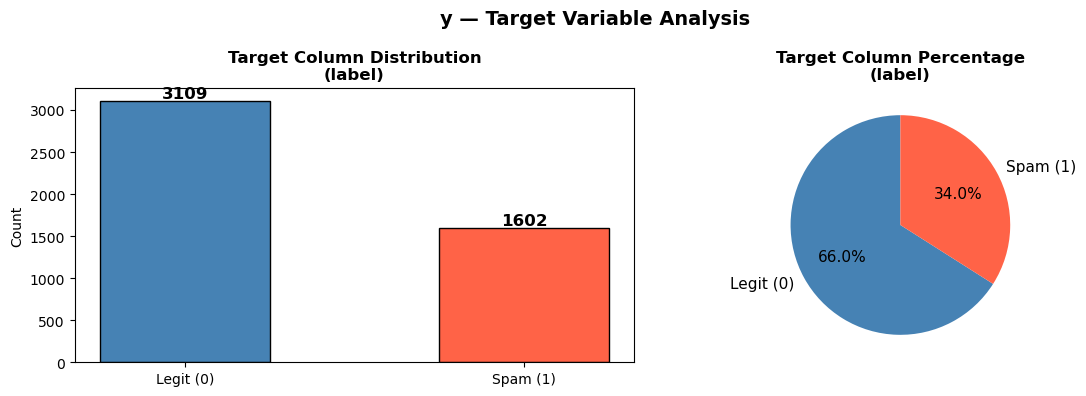

In [85]:
# ── Step 5: Visualize target distribution ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = y.value_counts()
bars = axes[0].bar(['Legit (0)', 'Spam (1)'], counts.values,
                    color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
for bar in bars:
    axes[0].annotate(f'{int(bar.get_height())}',
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Target Column Distribution\n(label)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(counts.values, labels=['Legit (0)', 'Spam (1)'],
            colors=['steelblue', 'tomato'], autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Target Column Percentage\n(label)', fontsize=12, fontweight='bold')

plt.suptitle('y — Target Variable Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [90]:
# ── Step 1: Basic 80/20 Split ──────────────────────────────────────────────
# test_size=0.2   → 20% goes to test,  80% goes to train
# random_state=42 → Ensures same split every time you run the code
# stratify=y      → Keeps same Spam/Legit ratio in both train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    X,              # Features
    y,              # Target
    test_size    = 0.2,   # 20% for testing
    random_state = 42,    # for reproducibility
    stratify     = y      # maintain class balance
)

print('=== Train / Test Split Results ===')
print(f'  Total dataset rows : {len(X)}')
print()
print(f'  X_train shape : {X_train.shape}  ← 80% of data — model trains on this')
print(f'  X_test  shape : {X_test.shape}   ← 20% of data — model is tested on this')
print()
print(f'  y_train shape : {y_train.shape}')
print(f'  y_test  shape : {y_test.shape}')

NameError: name 'train_test_split' is not defined

In [91]:
# ── Step 2: Verify class balance is maintained (stratify worked) ───────────
print('=== Class Balance Check ===')
print()
print('FULL dataset:')
print(f'  Spam  (1): {int(y.sum())}  ({y.mean()*100:.1f}%)')
print(f'  Legit (0): {int((y==0).sum())}  ({(1-y.mean())*100:.1f}%)')
print()
print('TRAINING set (80%):')
print(f'  Spam  (1): {int(y_train.sum())}  ({y_train.mean()*100:.1f}%)')
print(f'  Legit (0): {int((y_train==0).sum())}  ({(1-y_train.mean())*100:.1f}%)')
print()
print('TESTING set (20%):')
print(f'  Spam  (1): {int(y_test.sum())}  ({y_test.mean()*100:.1f}%)')
print(f'  Legit (0): {int((y_test==0).sum())}  ({(1-y_test.mean())*100:.1f}%)')
print()
print('✅ Spam/Legit ratio is same in Train and Test — stratify worked!')

=== Class Balance Check ===

FULL dataset:
  Spam  (1): 3109  (66.0%)
  Legit (0): 1602  (34.0%)

TRAINING set (80%):


NameError: name 'y_train' is not defined

NameError: name 'X_train' is not defined

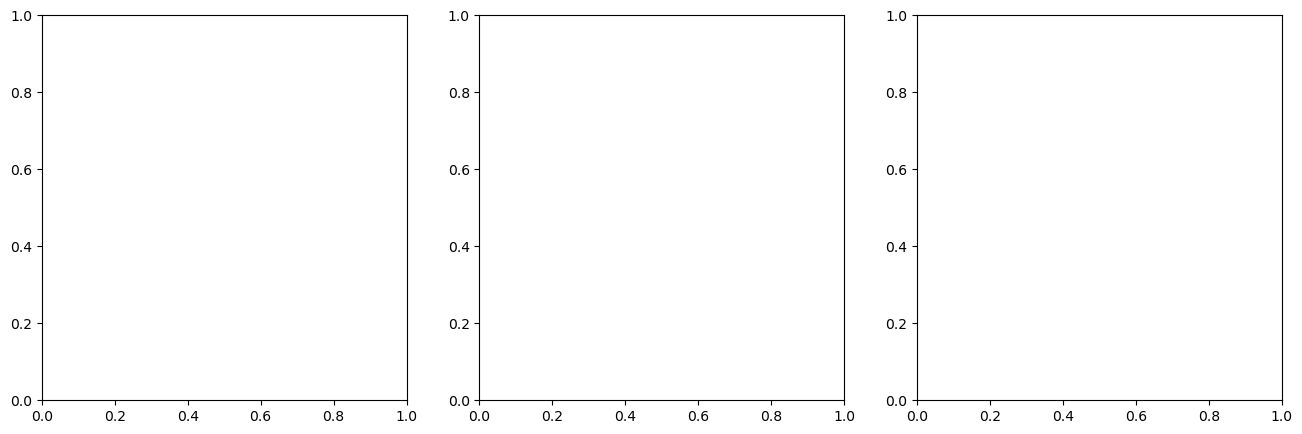

In [92]:
# ── Step 3: Visualize the Split ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall split sizes
axes[0].bar(['Training (80%)', 'Testing (20%)'],
            [len(X_train), len(X_test)],
            color=['#2196F3', '#FF5722'], edgecolor='black', width=0.4)
for i, v in enumerate([len(X_train), len(X_test)]):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Train vs Test Split Size', fontweight='bold')
axes[0].set_ylabel('Number of Rows')

# Class balance in training set
train_counts = y_train.value_counts()
axes[1].bar(['Legit (0)', 'Spam (1)'], train_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black', width=0.4)
for i, v in enumerate(train_counts.values):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Training Set\nClass Balance', fontweight='bold')
axes[1].set_ylabel('Count')

# Class balance in testing set
test_counts = y_test.value_counts()
axes[2].bar(['Legit (0)', 'Spam (1)'], test_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black', width=0.4)
for i, v in enumerate(test_counts.values):
    axes[2].text(i, v + 5, str(v), ha='center', fontsize=11, fontweight='bold')
axes[2].set_title('Testing Set\nClass Balance', fontweight='bold')
axes[2].set_ylabel('Count')

plt.suptitle('Train / Test Split Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [93]:
# ── Step 4: Other Split Ratios (for reference) ─────────────────────────────
# You can change test_size to any ratio
# Common choices: 0.2 (80/20), 0.25 (75/25), 0.3 (70/30)

print('=== Common Split Ratios for this dataset (4712 rows) ===')
for ratio in [0.10, 0.20, 0.25, 0.30]:
    train_n = int(len(X) * (1 - ratio))
    test_n  = int(len(X) * ratio)
    print(f'  test_size={ratio} → Train: {train_n} rows | Test: {test_n} rows')

print()
print('💡 Recommendation: Use test_size=0.2 (80/20 split) — most common choice')

=== Common Split Ratios for this dataset (4712 rows) ===
  test_size=0.1 → Train: 4239 rows | Test: 471 rows
  test_size=0.2 → Train: 3768 rows | Test: 942 rows
  test_size=0.25 → Train: 3533 rows | Test: 1177 rows
  test_size=0.3 → Train: 3297 rows | Test: 1413 rows

💡 Recommendation: Use test_size=0.2 (80/20 split) — most common choice


In [94]:
#SCALE AND NORMALIZE FEATURES

# ── Step 1: Check BEFORE scaling — see how different the scales are ─────────
print('=== Feature Ranges BEFORE Scaling ===')
print(f'{"Column":<30} {"Min":>10} {"Max":>12} {"Mean":>12} {"Std":>12}')
print('-' * 70)

check_cols = ['URLLength', 'DomainLength', 'URLSimilarityIndex',
              'IsHTTPS', 'NoOfImage', 'NoOfCSS', 'NoOfJS',
              'LineOfCode', 'LargestLineLength']

for col in check_cols:
    print(f'{col:<30} {X_train[col].min():>10.2f} {X_train[col].max():>12.2f} '
          f'{X_train[col].mean():>12.2f} {X_train[col].std():>12.2f}')

=== Feature Ranges BEFORE Scaling ===
Column                                Min          Max         Mean          Std
----------------------------------------------------------------------


NameError: name 'X_train' is not defined

In [95]:
# ── METHOD 1: StandardScaler ───────────────────────────────────────────────
# Formula: scaled = (X - mean) / std
# Result : Mean = 0, Std = 1

standard_scaler = StandardScaler()

# Fit on TRAINING data only, then transform
X_train_standard = standard_scaler.fit_transform(X_train)

# Transform TEST data using the SAME scaler (do NOT fit again!)
X_test_standard  = standard_scaler.transform(X_test)

# Convert back to DataFrame to see column names
X_train_standard = pd.DataFrame(X_train_standard, columns=X_train.columns)
X_test_standard  = pd.DataFrame(X_test_standard,  columns=X_test.columns)

print('=== StandardScaler Results ===')
print(f'X_train_standard shape: {X_train_standard.shape}')
print(f'X_test_standard  shape: {X_test_standard.shape}')
print()
print('Values AFTER StandardScaler (mean≈0, std≈1):')
print(X_train_standard[check_cols].describe().loc[['mean','std','min','max']].round(4))

NameError: name 'StandardScaler' is not defined

In [96]:
 ── METHOD 2: MinMaxScaler ─────────────────────────────────────────────────
# Formula: scaled = (X - X_min) / (X_max - X_min)
# Result : All values between 0 and 1

minmax_scaler = MinMaxScaler()

# Fit on TRAINING data only
X_train_minmax = minmax_scaler.fit_transform(X_train)

# Transform TEST data
X_test_minmax  = minmax_scaler.transform(X_test)

# Convert to DataFrame
X_train_minmax = pd.DataFrame(X_train_minmax, columns=X_train.columns)
X_test_minmax  = pd.DataFrame(X_test_minmax,  columns=X_test.columns)

print('=== MinMaxScaler Results ===')
print(f'X_train_minmax shape: {X_train_minmax.shape}')
print()
print('Values AFTER MinMaxScaler (all values between 0 and 1):')
print(X_train_minmax[check_cols].describe().loc[['mean','min','max']].round(4))

IndentationError: unexpected indent (3031017336.py, line 1)

In [97]:
# ── METHOD 3: RobustScaler ─────────────────────────────────────────────────
# Formula: scaled = (X - median) / IQR
# IQR = Q3 - Q1 (Interquartile Range)
# Not affected by extreme outliers

robust_scaler = RobustScaler()

# Fit on TRAINING data only
X_train_robust = robust_scaler.fit_transform(X_train)

# Transform TEST data
X_test_robust  = robust_scaler.transform(X_test)

# Convert to DataFrame
X_train_robust = pd.DataFrame(X_train_robust, columns=X_train.columns)
X_test_robust  = pd.DataFrame(X_test_robust,  columns=X_test.columns)

print('=== RobustScaler Results ===')
print(f'X_train_robust shape: {X_train_robust.shape}')
print()
print('Values AFTER RobustScaler (outlier-resistant):')
print(X_train_robust[check_cols].describe().loc[['mean','min','max']].round(4))

NameError: name 'RobustScaler' is not defined

NameError: name 'X_train' is not defined

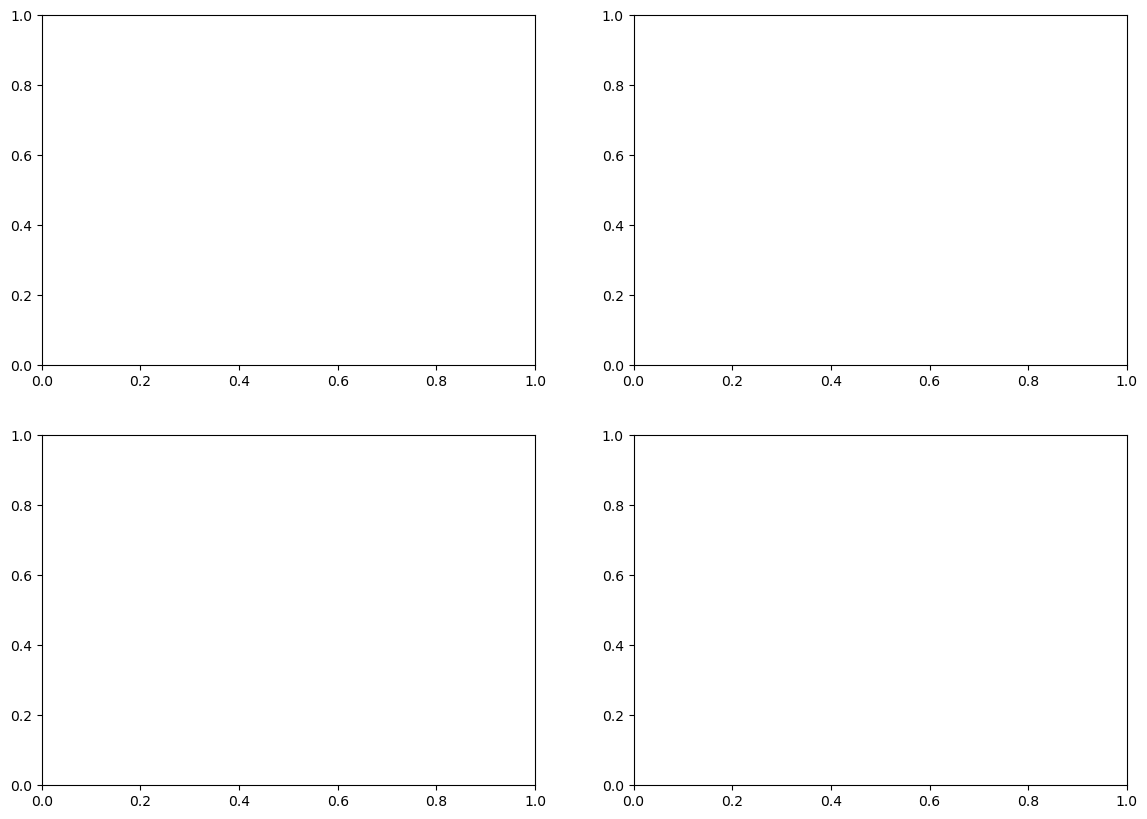

In [98]:
# ── Step 2: Compare all 3 scalers side by side for URLLength ───────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# BEFORE scaling
axes[0,0].hist(X_train['URLLength'], bins=60, color='gray', edgecolor='white', alpha=0.8)
axes[0,0].set_title('BEFORE Scaling\nURLLength', fontsize=11, fontweight='bold')
axes[0,0].set_xlabel('Value')
axes[0,0].set_ylabel('Count')

# StandardScaler
axes[0,1].hist(X_train_standard['URLLength'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,1].set_title('StandardScaler\n(mean=0, std=1)', fontsize=11, fontweight='bold')
axes[0,1].set_xlabel('Scaled Value')
axes[0,1].set_ylabel('Count')


In [99]:
# MinMaxScaler
axes[1,0].hist(X_train_minmax['URLLength'], bins=60, color='seagreen', edgecolor='white', alpha=0.8)
axes[1,0].set_title('MinMaxScaler\n(0 to 1)', fontsize=11, fontweight='bold')
axes[1,0].set_xlabel('Scaled Value')
axes[1,0].set_ylabel('Count')

# RobustScaler
axes[1,1].hist(X_train_robust['URLLength'], bins=60, color='tomato', edgecolor='white', alpha=0.8)
axes[1,1].set_title('RobustScaler\n(outlier-resistant)', fontsize=11, fontweight='bold')
axes[1,1].set_xlabel('Scaled Value')
axes[1,1].set_ylabel('Count')

plt.suptitle('URLLength — Before vs After Scaling (3 Methods)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()# ── Step 2: Compare all 3 scalers side by side for URLLength ───────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# BEFORE scaling
axes[0,0].hist(X_train['URLLength'], bins=60, color='gray', edgecolor='white', alpha=0.8)
axes[0,0].set_title('BEFORE Scaling\nURLLength', fontsize=11, fontweight='bold')
axes[0,0].set_xlabel('Value')
axes[0,0].set_ylabel('Count')

# StandardScaler
axes[0,1].hist(X_train_standard['URLLength'], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,1].set_title('StandardScaler\n(mean=0, std=1)', fontsize=11, fontweight='bold')
axes[0,1].set_xlabel('Scaled Value')
axes[0,1].set_ylabel('Count')


NameError: name 'X_train_minmax' is not defined

In [100]:
# ── Step 3: Compare ranges BEFORE and AFTER scaling ────────────────────────
compare_cols = ['URLLength', 'IsHTTPS', 'NoOfImage', 'LineOfCode']

print('=== Feature Ranges: BEFORE vs AFTER Scaling ===')
print()
print(f'{"Column":<22} {"BEFORE (min-max)":>18} {"StandardScaler":>18} {"MinMaxScaler":>15} {"RobustScaler":>15}')
print('-' * 95)

for col in compare_cols:
    before_range = f'{X_train[col].min():.1f} to {X_train[col].max():.1f}'
    std_range    = f'{X_train_standard[col].min():.2f} to {X_train_standard[col].max():.2f}'
    mm_range     = f'{X_train_minmax[col].min():.2f} to {X_train_minmax[col].max():.2f}'
    rob_range    = f'{X_train_robust[col].min():.2f} to {X_train_robust[col].max():.2f}'
    print(f'{col:<22} {before_range:>18} {std_range:>18} {mm_range:>15} {rob_range:>15}')

=== Feature Ranges: BEFORE vs AFTER Scaling ===

Column                   BEFORE (min-max)     StandardScaler    MinMaxScaler    RobustScaler
-----------------------------------------------------------------------------------------------


NameError: name 'X_train' is not defined

In [101]:
# ── RECOMMENDED for urlspam dataset: RobustScaler ──────────────────────────
# Reason: URLLength, NoOfImage, LineOfCode have heavy outliers
# RobustScaler handles outliers better than StandardScaler or MinMaxScaler

print('=== RECOMMENDED Scaler for this Dataset ===')
print()
print('  Choice : RobustScaler')
print('  Reason : This dataset has heavy outliers in:')
print('           URLLength     (max = 2048)')
print('           NoOfImage     (max = 2326)')
print('           LineOfCode    (max = very high)')
print('           LargestLineLength (max = very high)')
print()
print('  Rule of thumb:')
print('   StandardScaler → Use for most cases, no big outliers')
print('   MinMaxScaler   → Use when you need values between 0-1')
print('   RobustScaler   → Use when data HAS outliers (this dataset!)')

=== RECOMMENDED Scaler for this Dataset ===

  Choice : RobustScaler
  Reason : This dataset has heavy outliers in:
           URLLength     (max = 2048)
           NoOfImage     (max = 2326)
           LineOfCode    (max = very high)
           LargestLineLength (max = very high)

  Rule of thumb:
   StandardScaler → Use for most cases, no big outliers
   MinMaxScaler   → Use when you need values between 0-1
   RobustScaler   → Use when data HAS outliers (this dataset!)


In [102]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# ── 1. Load and clean ──────────────────────────────────────────────
df = pd.read_csv('urlspam.csv')
df[['NoOfImage','NoOfCSS','NoOfJS','NoOfSelfRef','NoOfEmptyRef','NoOfExternalRef']] = \
    df[['NoOfImage','NoOfCSS','NoOfJS','NoOfSelfRef','NoOfEmptyRef','NoOfExternalRef']].fillna(
    df[['NoOfImage','NoOfCSS','NoOfJS','NoOfSelfRef','NoOfEmptyRef','NoOfExternalRef']].median())
df['label'] = df['label'].fillna(df['label'].mode()[0])
df = df.drop(columns=['URL', 'Domain', 'Title', 'TLD'])

# ── 2. Separate X and y ────────────────────────────────────────────
X = df.drop(columns=['label'])   # Features — everything except label
y = df['label']                  # Target   — label column only

# ── 3. Train / Test Split ──────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

# ── 4. Scale the features ──────────────────────────────────────────
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit + Transform on train
X_test_scaled  = scaler.transform(X_test)        # Transform only on test

# Convert to DataFrame (optional, keeps column names)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X_test.columns)

# ── 5. Final check ─────────────────────────────────────────────────
print('=' * 50)
print('   ML DATA PREPARATION — COMPLETE!')
print('=' * 50)
print()
print(f'  X (all features)     : {X.shape}')
print(f'  y (target label)     : {y.shape}')
print()
print(f'  X_train_scaled shape : {X_train_scaled.shape}  ← 80% train')
print(f'  X_test_scaled  shape : {X_test_scaled.shape}   ← 20% test')
print(f'  y_train shape        : {y_train.shape}')
print(f'  y_test  shape        : {y_test.shape}')
print()
print(f'  Missing values       : {X_train_scaled.isnull().sum().sum()}')
print()
print('  ✅ Data is ready — you can now train your ML model!')
print()
print('  NEXT STEP — Train a model:')
print('  from sklearn.ensemble import RandomForestClassifier')
print('  model = RandomForestClassifier()')
print('  model.fit(X_train_scaled, y_train)')

   ML DATA PREPARATION — COMPLETE!

  X (all features)     : (4712, 50)
  y (target label)     : (4712,)

  X_train_scaled shape : (3769, 50)  ← 80% train
  X_test_scaled  shape : (943, 50)   ← 20% test
  y_train shape        : (3769,)
  y_test  shape        : (943,)

  Missing values       : 0

  ✅ Data is ready — you can now train your ML model!

  NEXT STEP — Train a model:
  from sklearn.ensemble import RandomForestClassifier
  model = RandomForestClassifier()
  model.fit(X_train_scaled, y_train)


In [103]:
# ── Data handling ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# ── ML: Data Preparation ───────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing   import RobustScaler

# ── ML: The Model ─────────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression    # ← Classification model
# from sklearn.linear_model import LinearRegression   # ← Use this for Regression

# ── ML: Evaluation Metrics ────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,          # Overall accuracy
    precision_score,         # How many predicted Spam are actually Spam
    recall_score,            # How many actual Spam were correctly found
    f1_score,                # Balance between Precision and Recall
    classification_report,   # Full report with all metrics
    confusion_matrix,        # Grid of correct vs wrong predictions
    roc_auc_score,           # Area Under ROC Curve
    roc_curve                # For plotting ROC curve
)

# ── Saving the model ──────────────────────────────────────────────────────
import joblib

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [ ]:
#LOGISTIC REGRESSION

In [104]:
# ── Create the Logistic Regression model ──────────────────────────────────
# max_iter=1000  → Allow up to 1000 iterations to find best coefficients
# random_state=42 → Reproducibility
# C=1.0          → Regularization strength (default 1.0 is good start)
# solver='lbfgs' → Algorithm used to optimize the model (default)

model = LogisticRegression(
    max_iter     = 1000,
    random_state = 42,
    C            = 1.0,
    solver       = 'lbfgs'
)

print('=== Logistic Regression Model Parameters ===')
print(model)
print()

=== Logistic Regression Model Parameters ===
LogisticRegression(max_iter=1000, random_state=42)



In [105]:
# ── Train (fit) the model on training data ─────────────────────────────────
# .fit() = The model LEARNS from X_train_scaled and y_train

print('Training the model...')
model.fit(X_train_scaled, y_train)
print('✅ Model training complete!')
print()
print(f'  Trained on : {X_train_scaled.shape[0]} rows')
print(f'  Features   : {X_train_scaled.shape[1]} columns')
print(f'  Classes    : {model.classes_.tolist()}')
print(f'  Iterations : {model.n_iter_[0]} (converged)')

Training the model...
✅ Model training complete!

  Trained on : 3769 rows
  Features   : 50 columns
  Classes    : [0.0, 1.0]
  Iterations : 17 (converged)


In [106]:
# ── predict() → Returns predicted class (0 or 1) ──────────────────────────
y_pred = model.predict(X_test_scaled)

# ── predict_proba() → Returns probability for each class ──────────────────
# Column 0 = probability of being Legit
# Column 1 = probability of being Spam
y_prob = model.predict_proba(X_test_scaled)

# Probability of being Spam (column 1) — used for ROC curve
y_prob_spam = y_prob[:, 1]

print('=== Predictions on Test Set ===')
print(f'  Total predictions    : {len(y_pred)}')
print(f'  Predicted as Legit   : {int((y_pred == 0).sum())}')
print(f'  Predicted as Spam    : {int((y_pred == 1).sum())}')
print()
# Show first 10 predictions side by side
results_preview = pd.DataFrame({
    'Actual'        : y_test.values[:10],
    'Predicted'     : y_pred[:10],
    'Prob_Legit'    : y_prob[:10, 0].round(4),
    'Prob_Spam'     : y_prob[:10, 1].round(4),
    'Correct'       : ['✅' if a==p else '❌'
                       for a, p in zip(y_test.values[:10], y_pred[:10])]
})
print('First 10 Predictions:')
print(results_preview.to_string(index=False))

=== Predictions on Test Set ===
  Total predictions    : 943
  Predicted as Legit   : 321
  Predicted as Spam    : 622

First 10 Predictions:
 Actual  Predicted  Prob_Legit  Prob_Spam Correct
    1.0        1.0      0.0000     1.0000       ✅
    1.0        1.0      0.0000     1.0000       ✅
    1.0        1.0      0.0000     1.0000       ✅
    1.0        1.0      0.0000     1.0000       ✅
    1.0        1.0      0.0000     1.0000       ✅
    1.0        1.0      0.0021     0.9979       ✅
    1.0        1.0      0.0000     1.0000       ✅
    1.0        1.0      0.0000     1.0000       ✅
    0.0        0.0      1.0000     0.0000       ✅
    1.0        1.0      0.0000     1.0000       ✅


In [107]:
# ── Core Metrics ──────────────────────────────────────────────────────────
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_prob_spam)

print('=' * 45)
print('   MODEL EVALUATION RESULTS')
print('=' * 45)
print(f'  Accuracy  : {accuracy  * 100:.2f}%')
print(f'  Precision : {precision * 100:.2f}%')
print(f'  Recall    : {recall    * 100:.2f}%')
print(f'  F1 Score  : {f1        * 100:.2f}%')
print(f'  ROC-AUC   : {roc_auc   :.4f}')
print('=' * 45)

if accuracy >= 0.99:
    print('  🏆 Excellent! Model performs perfectly.')
elif accuracy >= 0.90:
    print('  ✅ Great! Model performs very well.')
elif accuracy >= 0.80:
    print('  👍 Good model. Room for improvement.')
else:
    print('  ⚠️  Model needs improvement.')

   MODEL EVALUATION RESULTS
  Accuracy  : 100.00%
  Precision : 100.00%
  Recall    : 100.00%
  F1 Score  : 100.00%
  ROC-AUC   : 1.0000
  🏆 Excellent! Model performs perfectly.


In [108]:
# ── Full Classification Report ────────────────────────────────────────────
print('=== Full Classification Report ===')
print()
print(classification_report(
    y_test, y_pred,
    target_names=['Legit (0)', 'Spam (1)']
))
print('Columns explained:')
print('  precision → Out of all predicted Spam, how many are actually Spam')
print('  recall    → Out of all actual Spam,    how many did model catch')
print('  f1-score  → Balanced score of precision and recall')
print('  support   → Total real samples in that class')

=== Full Classification Report ===

              precision    recall  f1-score   support

   Legit (0)       1.00      1.00      1.00       321
    Spam (1)       1.00      1.00      1.00       622

    accuracy                           1.00       943
   macro avg       1.00      1.00      1.00       943
weighted avg       1.00      1.00      1.00       943

Columns explained:
  precision → Out of all predicted Spam, how many are actually Spam
  recall    → Out of all actual Spam,    how many did model catch
  f1-score  → Balanced score of precision and recall
  support   → Total real samples in that class


In [109]:
# ── Cross Validation (more reliable accuracy estimate) ─────────────────────
# Tests the model on 5 different splits and averages the results
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print('=== 5-Fold Cross Validation ===')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score * 100:.2f}%')
print(f'  ─────────────────────────')
print(f'  Mean  : {cv_scores.mean() * 100:.2f}%')
print(f'  Std   : {cv_scores.std()  * 100:.2f}%')
print()
print('  (Low Std = model is consistent across different data splits)')

=== 5-Fold Cross Validation ===
  Fold 1: 100.00%
  Fold 2: 100.00%
  Fold 3: 99.73%
  Fold 4: 100.00%
  Fold 5: 100.00%
  ─────────────────────────
  Mean  : 99.95%
  Std   : 0.11%

  (Low Std = model is consistent across different data splits)


In [110]:
#VISUALIZE THE RESULT
# ── Cross Validation (more reliable accuracy estimate) ─────────────────────
# Tests the model on 5 different splits and averages the results
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print('=== 5-Fold Cross Validation ===')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score * 100:.2f}%')
print(f'  ─────────────────────────')
print(f'  Mean  : {cv_scores.mean() * 100:.2f}%')
print(f'  Std   : {cv_scores.std()  * 100:.2f}%')
print()
print('  (Low Std = model is consistent across different data splits)')

=== 5-Fold Cross Validation ===
  Fold 1: 100.00%
  Fold 2: 100.00%
  Fold 3: 99.73%
  Fold 4: 100.00%
  Fold 5: 100.00%
  ─────────────────────────
  Mean  : 99.95%
  Std   : 0.11%

  (Low Std = model is consistent across different data splits)


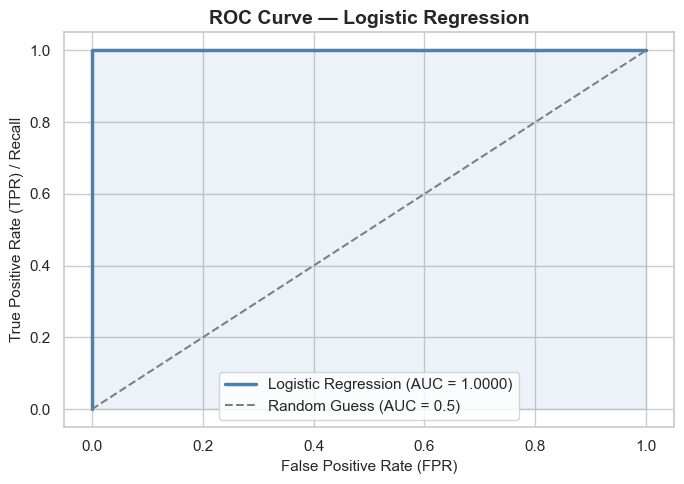

  ROC-AUC Score : 1.0000
  Interpretation: Perfect classifier!


In [111]:
# ── 9B: ROC Curve ─────────────────────────────────────────────────────────
# ROC Curve shows the tradeoff between True Positive Rate and False Positive Rate
# AUC = Area Under Curve: closer to 1.0 = better model

fpr, tpr, thresholds = roc_curve(y_test, y_prob_spam)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', linewidth=2.5,
         label=f'Logistic Regression (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         linewidth=1.5, label='Random Guess (AUC = 0.5)')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate (TPR) / Recall', fontsize=11)
plt.title('ROC Curve — Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'  ROC-AUC Score : {roc_auc:.4f}')
print(f'  Interpretation: {"Perfect classifier!" if roc_auc >= 0.99 else "Good classifier" if roc_auc >= 0.90 else "Needs improvement"}')

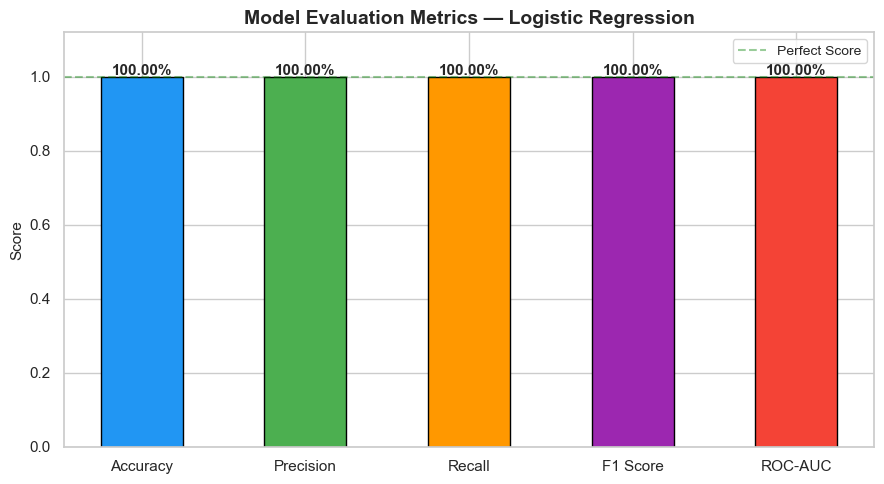

In [112]:
# ── 9C: All Metrics in One Bar Chart ──────────────────────────────────────
metrics = {
    'Accuracy' : accuracy,
    'Precision': precision,
    'Recall'   : recall,
    'F1 Score' : f1,
    'ROC-AUC'  : roc_auc
}

colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336']

plt.figure(figsize=(9, 5))
bars = plt.bar(metrics.keys(), metrics.values(),
               color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, metrics.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{val*100:.2f}%', ha='center',
             fontsize=11, fontweight='bold')

plt.ylim(0, 1.12)
plt.ylabel('Score', fontsize=11)
plt.title('Model Evaluation Metrics — Logistic Regression',
          fontsize=14, fontweight='bold')
plt.axhline(y=1.0, color='green', linestyle='--', alpha=0.4, label='Perfect Score')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

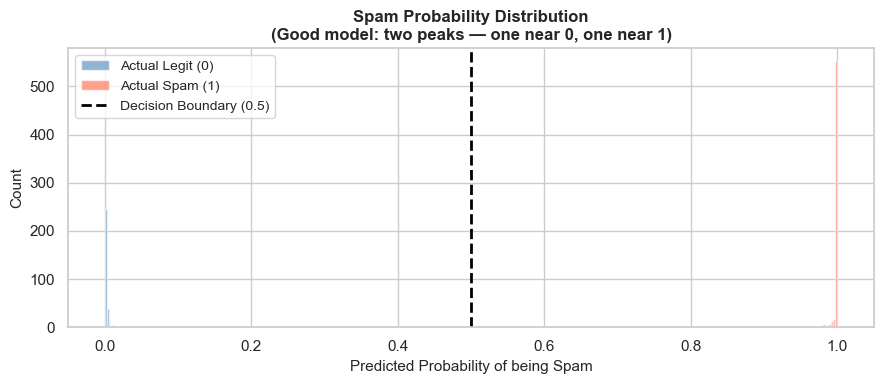

In [113]:
# ── 9D: Probability Distribution — How confident is the model? ─────────────
plt.figure(figsize=(9, 4))

# Spam probabilities for actual Legit URLs
prob_legit = y_prob_spam[y_test == 0]
# Spam probabilities for actual Spam URLs
prob_spam  = y_prob_spam[y_test == 1]

plt.hist(prob_legit, bins=50, alpha=0.6, color='steelblue',
         edgecolor='white', label='Actual Legit (0)')
plt.hist(prob_spam,  bins=50, alpha=0.6, color='tomato',
         edgecolor='white', label='Actual Spam (1)')
plt.axvline(x=0.5, color='black', linestyle='--',
            linewidth=2, label='Decision Boundary (0.5)')

plt.xlabel('Predicted Probability of being Spam', fontsize=11)
plt.ylabel('Count', fontsize=11)
plt.title('Spam Probability Distribution\n(Good model: two peaks — one near 0, one near 1)',
          fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

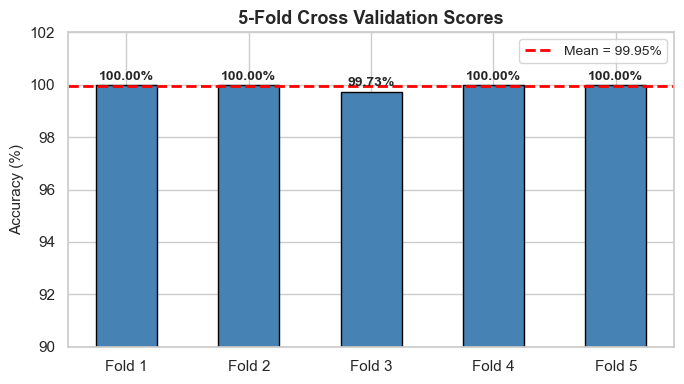

In [114]:
# ── 9E: Cross Validation Scores Plot ──────────────────────────────────────
plt.figure(figsize=(7, 4))
bars = plt.bar([f'Fold {i}' for i in range(1, 6)],
               cv_scores * 100,
               color='steelblue', edgecolor='black', width=0.5)

for bar, val in zip(bars, cv_scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{val*100:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.axhline(y=cv_scores.mean()*100, color='red', linestyle='--',
            linewidth=2, label=f'Mean = {cv_scores.mean()*100:.2f}%')
plt.ylim(90, 102)
plt.ylabel('Accuracy (%)', fontsize=11)
plt.title('5-Fold Cross Validation Scores', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [115]:
#FEATURE IMPORTANCE
# ── Get feature importance from model coefficients ─────────────────────────
# model.coef_[0] gives the coefficient for each feature
# Positive coefficient → feature pushes prediction toward Spam (1)
# Negative coefficient → feature pushes prediction toward Legit (0)

feature_importance = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_[0],
    'Abs_Coef'   : np.abs(model.coef_[0])
}).sort_values('Abs_Coef', ascending=False)

print('=== Top 15 Most Important Features ===')
print(feature_importance.head(15).to_string(index=False))

=== Top 15 Most Important Features ===
           Feature  Coefficient  Abs_Coef
URLSimilarityIndex     3.127989  3.127989
           IsHTTPS     2.912363  2.912363
  HasCopyrightInfo     1.296121  1.296121
    HasDescription     1.192099  1.192099
      HasSocialNet     1.161344  1.161344
         NoOfImage     1.093134  1.093134
        LineOfCode     0.961019  0.961019
           NoOfCSS     0.910496  0.910496
   NoOfExternalRef     0.909383  0.909383
            NoOfJS     0.853992  0.853992
        HasFavicon     0.846410  0.846410
  LetterRatioInURL    -0.745962  0.745962
       NoOfSelfRef     0.712037  0.712037
   NoOfDegitsInURL    -0.634243  0.634243
   HasHiddenFields     0.606480  0.606480


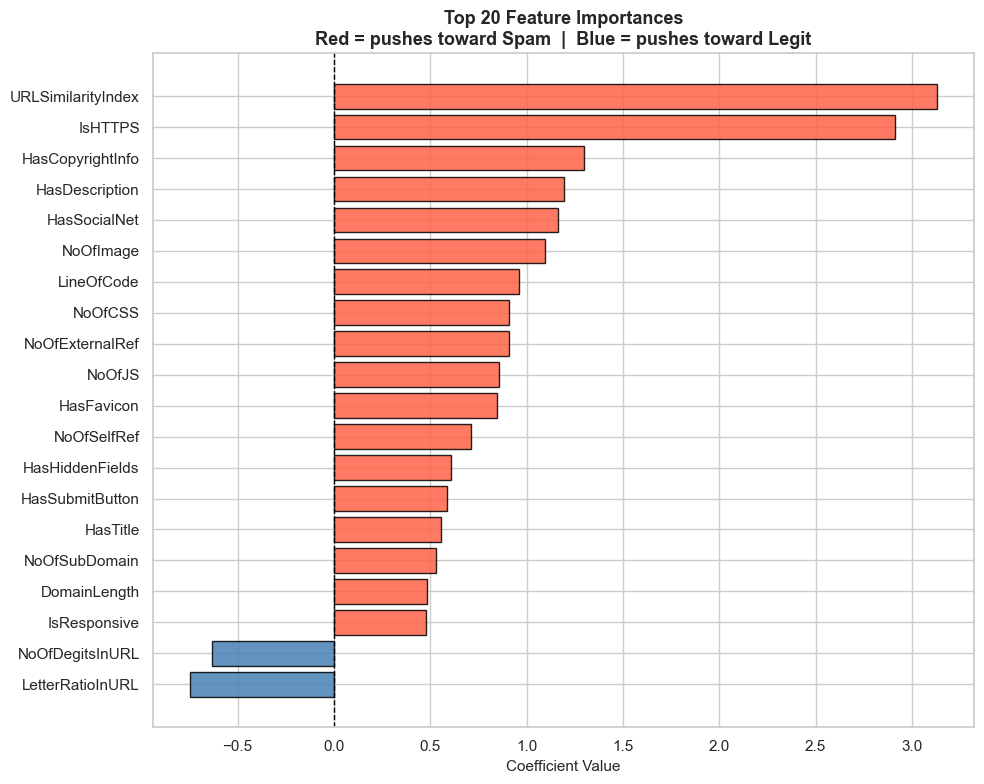


Top 5 features that INCREASE Spam prediction (positive):
           Feature  Coefficient
URLSimilarityIndex     3.127989
           IsHTTPS     2.912363
  HasCopyrightInfo     1.296121
    HasDescription     1.192099
      HasSocialNet     1.161344

Top 5 features that DECREASE Spam prediction (negative):
                   Feature  Coefficient
          LetterRatioInURL    -0.745962
           NoOfDegitsInURL    -0.634243
     SpacialCharRatioInURL    -0.436999
NoOfOtherSpecialCharsInURL    -0.403951
         LargestLineLength    -0.277931


In [116]:
# ── Visualize Top 20 features ─────────────────────────────────────────────
top20 = feature_importance.head(20).sort_values('Coefficient')
colors = ['tomato' if v > 0 else 'steelblue' for v in top20['Coefficient']]

plt.figure(figsize=(10, 8))
plt.barh(top20['Feature'], top20['Coefficient'],
         color=colors, edgecolor='black', alpha=0.85)
plt.axvline(x=0, color='black', linewidth=1, linestyle='--')
plt.xlabel('Coefficient Value', fontsize=11)
plt.title('Top 20 Feature Importances\n'
          'Red = pushes toward Spam  |  Blue = pushes toward Legit',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print()
print('Top 5 features that INCREASE Spam prediction (positive):')
print(feature_importance[feature_importance['Coefficient'] > 0].head(5)[['Feature','Coefficient']].to_string(index=False))
print()
print('Top 5 features that DECREASE Spam prediction (negative):')
print(feature_importance[feature_importance['Coefficient'] < 0].head(5)[['Feature','Coefficient']].to_string(index=False))

In [118]:
# ── Predict on a single sample from the test set ──────────────────────────

def predict_url(sample_index):
    """
    Predict whether a URL is Spam or Legit.
    sample_index: index from X_test to predict
    """
    sample        = X_test_scaled[sample_index].reshape(1, -1)
    prediction    = model.predict(sample)[0]
    probability   = model.predict_proba(sample)[0]
    actual        = y_test.values[sample_index]

    label_map = {0.0: 'LEGIT ✅', 1.0: 'SPAM 🚨'}

    print(f'=== URL Prediction (Sample #{sample_index}) ===')
    print(f'  Actual Answer    : {label_map[actual]}')
    print(f'  Model Predicted  : {label_map[prediction]}')
    print(f'  Prob Legit (0)   : {probability[0]*100:.2f}%')
    print(f'  Prob Spam  (1)   : {probability[1]*100:.2f}%')
    print(f'  Correct?         : {"✅ YES" if prediction == actual else "❌ NO"}')

# Test on 3 different samples
predict_url(0)
print()
predict_url(10)
print()
predict_url(25)

KeyError: 0

In [119]:
# ── Batch prediction on multiple samples ──────────────────────────────────
# Predict on first 10 test samples and show results

batch_results = pd.DataFrame({
    'Actual'     : y_test.values[:10],
    'Predicted'  : y_pred[:10],
    'Prob_Legit' : (y_prob[:10, 0] * 100).round(2),
    'Prob_Spam'  : (y_prob[:10, 1] * 100).round(2),
    'Result'     : ['✅ Correct' if a == p else '❌ Wrong'
                    for a, p in zip(y_test.values[:10], y_pred[:10])]
})

batch_results['Actual']    = batch_results['Actual'].map({0.0: 'Legit', 1.0: 'Spam'})
batch_results['Predicted'] = batch_results['Predicted'].map({0.0: 'Legit', 1.0: 'Spam'})

print('=== Batch Predictions — First 10 Samples ===')
print(batch_results.to_string(index=False))

=== Batch Predictions — First 10 Samples ===
Actual Predicted  Prob_Legit  Prob_Spam    Result
  Spam      Spam        0.00     100.00 ✅ Correct
  Spam      Spam        0.00     100.00 ✅ Correct
  Spam      Spam        0.00     100.00 ✅ Correct
  Spam      Spam        0.00     100.00 ✅ Correct
  Spam      Spam        0.00     100.00 ✅ Correct
  Spam      Spam        0.21      99.79 ✅ Correct
  Spam      Spam        0.00     100.00 ✅ Correct
  Spam      Spam        0.00     100.00 ✅ Correct
 Legit     Legit      100.00       0.00 ✅ Correct
  Spam      Spam        0.00     100.00 ✅ Correct


In [120]:
# ── Save the trained model and scaler ─────────────────────────────────────
# joblib saves the model to a file so you can reuse it later
# without retraining

joblib.dump(model,  'logistic_regression_urlspam.pkl')
joblib.dump(scaler, 'scaler_urlspam.pkl')

print('✅ Model and Scaler saved!')
print()
print('  Files saved:')
print('    logistic_regression_urlspam.pkl  ← trained model')
print('    scaler_urlspam.pkl               ← fitted scaler')
print()
print('  To reload and use later:')
print('    loaded_model  = joblib.load("logistic_regression_urlspam.pkl")')
print('    loaded_scaler = joblib.load("scaler_urlspam.pkl")')
print('    new_scaled    = loaded_scaler.transform(new_data)')
print('    prediction    = loaded_model.predict(new_scaled)')

✅ Model and Scaler saved!

  Files saved:
    logistic_regression_urlspam.pkl  ← trained model
    scaler_urlspam.pkl               ← fitted scaler

  To reload and use later:
    loaded_model  = joblib.load("logistic_regression_urlspam.pkl")
    loaded_scaler = joblib.load("scaler_urlspam.pkl")
    new_scaled    = loaded_scaler.transform(new_data)
    prediction    = loaded_model.predict(new_scaled)


In [121]:
# ── Load and test the saved model ─────────────────────────────────────────
loaded_model  = joblib.load('logistic_regression_urlspam.pkl')
loaded_scaler = joblib.load('scaler_urlspam.pkl')

# Test the loaded model
test_pred = loaded_model.predict(X_test_scaled[:5])
print('=== Loaded Model Test — First 5 Predictions ===')
for i, (actual, predicted) in enumerate(zip(y_test.values[:5], test_pred)):
    status = '✅' if actual == predicted else '❌'
    print(f'  Sample {i+1}: Actual={int(actual)} | Predicted={int(predicted)} {status}')
print()
print('✅ Model loaded and working correctly!')

=== Loaded Model Test — First 5 Predictions ===
  Sample 1: Actual=1 | Predicted=1 ✅
  Sample 2: Actual=1 | Predicted=1 ✅
  Sample 3: Actual=1 | Predicted=1 ✅
  Sample 4: Actual=1 | Predicted=1 ✅
  Sample 5: Actual=1 | Predicted=1 ✅

✅ Model loaded and working correctly!
